In [1]:
%cd ../

/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/models/experimentation/stamp_rubin


In [2]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
results_file_name = 'results_real_rubin_finetuning_synthetic_to_real'

In [4]:
mlflow.set_tracking_uri(f"file:./{results_file_name}/ml-runs")

experiment_name = f"classification/rubin_real/testing"

experiment = mlflow.get_experiment_by_name(experiment_name)
if experiment:
    experiment_id = experiment.experiment_id
    print(f"Experiment ID for '{experiment_name}': {experiment_id}")
else:
    print(f"Experiment '{experiment_name}' not found.")

runs = mlflow.search_runs(experiment_ids=[experiment_id])
runs = runs[
    (runs.status == 'FINISHED')
    ]

# Identificadores de cada fold
#fold_run = {v: k for k, v in zip(runs['run_id'], runs['params.general/fold'])}

display(runs.head())
print(runs.shape)
#print(fold_run)

Experiment ID for 'classification/rubin_real/testing': 152702854558869573


,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.train_loss,metrics.train_accuracy,metrics.val_accuracy,metrics.val_f1,...,metrics.val_loss,metrics.train_f1,metrics.train_accuracy_running,metrics.test_recall,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.parentRunId,tags.mlflow.source.git.commit,tags.mlflow.user,tags.mlflow.source.name
0,b2e5ca5cdf96461fa14c278457b0b5da,152702854558869573,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2025-12-05 01:00:31.906000+00:00,2025-12-05 01:02:28.739000+00:00,0.198909,0.924473,0.861244,0.771192,...,0.310713,0.918512,0.917969,0.784743,LOCAL,Fold_4_2025-12-05_00-49-53,0728c53a47b04a578feb26ffd598444c,6ed63fd1e72375e122564f67cd157af5f7605281,dmoreno,finetuning_tf_custom.py
1,289f9d12d9b3419e8539c9c3a11a6c43,152702854558869573,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2025-12-05 00:58:08.026000+00:00,2025-12-05 01:00:31.896000+00:00,0.171639,0.935335,0.895666,0.829328,...,0.268471,0.935897,0.941406,0.764266,LOCAL,Fold_3_2025-12-05_00-49-53,0728c53a47b04a578feb26ffd598444c,6ed63fd1e72375e122564f67cd157af5f7605281,dmoreno,finetuning_tf_custom.py
2,e2456097d3e648df85ad78d7e505c015,152702854558869573,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2025-12-05 00:54:25.503000+00:00,2025-12-05 00:58:08.014000+00:00,0.194973,0.924552,0.885167,0.858540,...,0.263932,0.919239,0.933594,0.774605,LOCAL,Fold_2_2025-12-05_00-49-53,0728c53a47b04a578feb26ffd598444c,6ed63fd1e72375e122564f67cd157af5f7605281,dmoreno,finetuning_tf_custom.py
3,b246b05ac6d240dba1083728b9322aed,152702854558869573,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2025-12-05 00:52:33.654000+00:00,2025-12-05 00:54:25.491000+00:00,0.207165,0.921956,0.880573,0.830188,...,0.310101,0.916314,0.937500,0.784743,LOCAL,Fold_1_2025-12-05_00-49-53,0728c53a47b04a578feb26ffd598444c,6ed63fd1e72375e122564f67cd157af5f7605281,dmoreno,finetuning_tf_custom.py
4,139b8b788f8f402fbec1819971d7182c,152702854558869573,FINISHED,file:///home/dmoreno/pipeline_v4_final/pipelin...,2025-12-05 00:49:53.355000+00:00,2025-12-05 00:52:33.650000+00:00,0.150064,0.942899,0.838710,0.736453,...,0.417431,0.944062,0.929688,0.782947,LOCAL,Fold_0_2025-12-05_00-49-53,0728c53a47b04a578feb26ffd598444c,6ed63fd1e72375e122564f67cd157af5f7605281,dmoreno,finetuning_tf_custom.py


(12, 23)


In [5]:
runs.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.train_loss', 'metrics.train_accuracy',
       'metrics.val_accuracy', 'metrics.val_f1', 'metrics.train_loss_running',
       'metrics.test_precision', 'metrics.test_f1', 'metrics.val_loss',
       'metrics.train_f1', 'metrics.train_accuracy_running',
       'metrics.test_recall', 'tags.mlflow.source.type', 'tags.mlflow.runName',
       'tags.mlflow.parentRunId', 'tags.mlflow.source.git.commit',
       'tags.mlflow.user', 'tags.mlflow.source.name'],
      dtype='object')

In [6]:
runs['run_name'] = runs['tags.mlflow.runName'].apply(lambda row: '_'.join(row.split('_')[-2:]))
runs['run_name']

0     2025-12-05_00-49-53
1     2025-12-05_00-49-53
2     2025-12-05_00-49-53
3     2025-12-05_00-49-53
4     2025-12-05_00-49-53
5     2025-12-05_00-49-53
6     2025-12-04_23-23-07
7     2025-12-04_23-23-07
8     2025-12-04_23-23-07
9     2025-12-04_23-23-07
10    2025-12-04_23-23-07
11    2025-12-04_23-23-07
Name: run_name, dtype: object

In [7]:
# --- El nuevo código para agrupar y promediar ---

# 1. Define las métricas que te interesan promediar.
#    Asegúrate de que los nombres coincidan exactamente con las columnas del DataFrame.
metric_cols = [
    'metrics.val_f1',
    'metrics.train_f1',
    'metrics.train_loss',
    # Agrega aquí cualquier otra métrica que quieras promediar
    'metrics.val_loss',
    'metrics.val_accuracy',
    'metrics.test_f1',
    'metrics.test_precision',
    'metrics.test_recall',
]
# Filtra para solo usar las métricas que existen en tu dataframe
metric_cols_exist = [col for col in metric_cols if col in runs.columns]


# 2. Define los hiperparámetros que identifican cada experimento.
#    Queremos mantenerlos para saber qué combinación de hiperparámetros dio qué resultado.
param_cols = [col for col in runs.columns if col.startswith('params.')]


# 3. Agrupa por el ID del "Run padre" y realiza las agregaciones.
#    - Para las métricas: calcula la media ('mean') y la desviación estándar ('std').
#    - Para los parámetros: toma el primer valor ('first'), ya que son iguales para todo el grupo.
agg_dict = {**{col: ['mean', 'std'] for col in metric_cols_exist}, 
            **{col: 'first' for col in param_cols}}

# Elimina las columnas que no existen en el dataframe para evitar errores
agg_dict = {k: v for k, v in agg_dict.items() if k in runs.columns}

# Realiza la agrupación
# Nota: filtramos los runs que no tienen un parentRunId, que suelen ser los propios "runs padres"
#results_by_hp = runs.dropna(subset=['tags.mlflow.parentRunId']).groupby('tags.mlflow.parentRunId').agg(agg_dict)
results_by_hp = runs.dropna(subset=['run_name']).groupby('run_name').agg(agg_dict)


# 4. (Opcional pero recomendado) Limpia los nombres de las columnas para que sean más manejables.
results_by_hp.columns = ['_'.join(col).strip() for col in results_by_hp.columns.values]
# Renombramos las columnas de los parámetros para quitar el '_first'
results_by_hp = results_by_hp.rename(columns=lambda col: col.replace('_first', '') if '_first' in col else col)


# 5. Ordena los resultados para ver los mejores hiperparámetros primero.
#    Por ejemplo, ordenar por la media del F1-score de validación de forma descendente.
best_results = results_by_hp.sort_values('metrics.test_f1_mean', ascending=False)

# Muestra los resultados
print("Resultados promediados por set de hiperparámetros:")
# También puedes ver solo las columnas más importantes
display(best_results[[
    'metrics.test_f1_mean', 
    'metrics.test_f1_std',
    'metrics.val_f1_mean', 
    'metrics.val_f1_std',
    # Agrega más columnas de parámetros y métricas que quieras ver
]].head(10))

Resultados promediados por set de hiperparámetros:


,metrics.test_f1_mean,metrics.test_f1_std,metrics.val_f1_mean,metrics.val_f1_std
run_name,,,,
2025-12-05_00-49-53,0.765652,0.011533,0.805140,0.049836
2025-12-04_23-23-07,0.751556,0.011213,0.776473,0.051940


In [8]:
run_name = best_results.index[0]
run_name

'2025-12-05_00-49-53'

In [9]:
fold_run = runs[runs['run_name'] == run_name].dropna()

In [10]:
for idx, row in fold_run.iterrows():
    experiment_id = row['experiment_id']
    run_id = row['run_id']
    path_pred = f'./{results_file_name}/ml-runs/{experiment_id}/{run_id}/artifacts/test_predictions.csv'
    predictions = pd.read_csv(path_pred)
    print(predictions)
    break

                    oid      measurement_id  true_label_int  \
0    169342391479697434  169342391479697434               4   
1    169342391520592115  169342391520592115               4   
2    169342391522689127  169364381640949779               4   
3    169342391608147991  169342391608147991               4   
4    169342391654809731  169342391654809731               4   
..                  ...                 ...             ...   
784  169562328094736421  169562328094736421               4   
785  169562328094736476  169562328094736476               4   
786  169562328169709617  169562328169709617               4   
787  169562328976588853  169562328976588853               4   
788  169562328999133242  169562328999133242               4   

     predicted_label_int true_label predicted_label  predicted_probability  \
0                      4      bogus           bogus               0.465238   
1                      4      bogus           bogus               0.989326   
2        

In [11]:
predictions

,oid,measurement_id,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,prob_asteroid,prob_bogus
0,169342391479697434,169342391479697434,4,4,bogus,bogus,0.465238,0.079728,0.000030,0.454875,0.000128,0.465238
1,169342391520592115,169342391520592115,4,4,bogus,bogus,0.989326,0.000118,0.000006,0.000347,0.010203,0.989326
2,169342391522689127,169364381640949779,4,4,bogus,bogus,0.950906,0.001551,0.000015,0.042061,0.005467,0.950906
3,169342391608147991,169342391608147991,4,4,bogus,bogus,0.975581,0.000228,0.000027,0.000176,0.023988,0.975581
4,169342391654809731,169342391654809731,4,0,bogus,AGN,0.782874,0.782874,0.014604,0.003202,0.001299,0.198020
...,...,...,...,...,...,...,...,...,...,...,...,...
784,169562328094736421,169562328094736421,4,4,bogus,bogus,0.997039,0.000068,0.000001,0.000364,0.002528,0.997039
785,169562328094736476,169562328094736476,4,4,bogus,bogus,0.996434,0.000079,0.000002,0.000320,0.003165,0.996434
786,169562328169709617,169562328169709617,4,4,bogus,bogus,0.977058,0.000539,0.000057,0.000505,0.021842,0.977058
787,169562328976588853,169562328976588853,4,4,bogus,bogus,0.960934,0.000235,0.000008,0.000977,0.037846,0.960934


In [12]:
test_used = pd.read_parquet('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/processed/partitions/partitions_trainSN_mixed_valSN_real_eval_firstStamp_v1/partitions.parquet')
test_used = test_used[test_used['partition'] == 'test']
test_used

,oid,oid_kept,measurement_id,band,ra,dec,mjd,class,partition,dataset_origin,synth_file_path
120,169302853546934853,169302853546934853,169302853546934853,i,7.726246,-43.727943,60925.272422,AGN,test,real,None
121,169302853546934853,169302853546934853,169584316951560199,g,7.726494,-43.727955,60989.204733,AGN,test,real,None
122,169302853546934853,169302853546934853,169593097454878756,g,7.72654,-43.727981,60991.237618,AGN,test,real,None
123,169302853546934853,169302853546934853,169606277929369839,g,7.726272,-43.727973,60994.083784,AGN,test,real,None
234,169342390653944012,169342390653944012,169342390653944012,g,8.234595,-42.731144,60934.116039,AGN,test,real,None
...,...,...,...,...,...,...,...,...,...,...,...
37057,611257134226611503,611257134226611503,648367026053579334,i,<NA>,<NA>,<NA>,SN,test,synthetic,611257134226611503_i_2024112900276_2_648367026...
37058,611257134226611503,611257134226611503,614439120877388319,u,<NA>,<NA>,<NA>,SN,test,synthetic,611257134226611503_u_2024120100160_0_614439120...
37059,611257134226611503,611257134226611503,648367026053579334,i,<NA>,<NA>,<NA>,SN,test,synthetic,611257134226611503_i_2024112900276_2_648367026...
37060,611257134226611503,611257134226611503,648372111294857345,i,<NA>,<NA>,<NA>,SN,test,synthetic,611257134226611503_i_2024112900276_2_648372111...


In [13]:
oid_test_used = test_used.oid.values
oid_test_used

array([169302853546934853, 169302853546934853, 169302853546934853, ...,
       611257134226611503, 611257134226611503, 611257134226611503])

In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
# En Jupyter/Colab, display() muestra los DataFrames de forma más bonita
from IPython.display import display 

# --- Tu código inicial para seleccionar los runs de un experimento específico ---
# Asumo que 'runs' ya es un DataFrame cargado con mlflow.search_runs()
# runs['run_name'] = runs['tags.mlflow.runName'].apply(lambda row: '_'.join(row.split('_')[-2:]))
fold_run = runs[runs['run_name'] == run_name]

# --- Listas para almacenar los resultados de cada fold ---
all_confusion_matrices = []
all_confusion_matrices_norm = []
all_classification_reports = []
class_names = [] # Para guardar los nombres de las clases (ej: 'AGN', 'VS')
class_labels = [] # Para guardar las etiquetas numéricas (ej: 0, 2)
all_predictions = []
all_predictions_sim = []

# --- 1. Iterar y recolectar resultados de cada fold ---
print(f"Procesando {len(fold_run)} folds para el experimento {run_name}...\n")

for idx, row in fold_run.iterrows():
    experiment_id = row['experiment_id']
    run_id = row['run_id']
    fold_num = row.get('params.general/fold', 'N/A') # Intenta obtener el número de fold
    path_pred = f'./{results_file_name}/ml-runs/{experiment_id}/{run_id}/artifacts/test_predictions.csv'
    
    try:
        predictions = pd.read_csv(path_pred)
        #predictions = predictions[predictions.oid.isin(oid_test_used)] ########################################################
        
        all_predictions_sim.append(pd.read_csv(f'./{results_file_name}/ml-runs/{experiment_id}/{run_id}/artifacts/test_sim_predictions.csv'))
        

        y_true = predictions['true_label_int']
        y_pred = predictions['predicted_label_int']
        
        # En la primera iteración, obtenemos los nombres y etiquetas de las clases
        if not class_names:
            # Ordenamos por la etiqueta numérica para asegurar un orden consistente
            labels_df = predictions[['true_label_int', 'true_label']].drop_duplicates().sort_values('true_label_int')
            class_labels = labels_df['true_label_int'].tolist()
            class_names = labels_df['true_label'].tolist()
            print(f"Clases detectadas (en orden): {class_names}")

        all_predictions.append(predictions)

        # a) Calcular y guardar la matriz de confusión
        # Usamos `labels=class_labels` para asegurar que todas las matrices tengan el mismo tamaño y orden
        cm = confusion_matrix(y_true, y_pred, labels=class_labels)
        all_confusion_matrices.append(cm)

        cm_norm = confusion_matrix(y_true, y_pred, labels=class_labels, normalize='true')
        all_confusion_matrices_norm.append(cm_norm)
        
        # b) Calcular y guardar el reporte de clasificación (como diccionario)
        report = classification_report(
            y_true, 
            y_pred, 
            labels=class_labels, 
            target_names=class_names, 
            output_dict=True,
            zero_division=0 # Evita warnings si una clase no tiene predicciones
        )
        all_classification_reports.append(report)
        
    except FileNotFoundError:
        print(f"ADVERTENCIA: No se encontró el archivo de predicciones para el run_id: {run_id}")
    except Exception as e:
        print(f"Ocurrió un error procesando el run_id {run_id}: {e}")

# --- 2. Procesar y promediar los resultados recolectados ---

# --- a) Matriz de Confusión ---
if all_confusion_matrices:
    # Convertimos la lista de matrices 2D en un array 3D de NumPy
    cm_stack = np.stack(all_confusion_matrices, axis=0)
    mean_cm = np.mean(cm_stack, axis=0)
    std_cm = np.std(cm_stack, axis=0)

    cm_norm_stack = np.stack(all_confusion_matrices_norm, axis=0)
    mean_cm_norm = np.mean(cm_norm_stack, axis=0)
    std_cm_norm = np.std(cm_norm_stack, axis=0)
    
    # Creamos DataFrames para una visualización clara
    mean_cm_df = pd.DataFrame(mean_cm, index=class_names, columns=class_names)
    std_cm_df = pd.DataFrame(std_cm, index=class_names, columns=class_names)
    
    print("\n" + "="*50)
    print("       MATRIZ DE CONFUSIÓN (PROMEDIO Y STD)")
    print("="*50)
    print("\n--- Matriz de Confusión Promedio (número de muestras) ---")
    print("Filas: Etiqueta Verdadera, Columnas: Etiqueta Predicha")
    display(mean_cm_df.round(2))
    
    print("\n--- Desviación Estándar de la Matriz de Confusión ---")
    display(std_cm_df.round(2))

else:
    print("\nNo se encontraron matrices de confusión para procesar.")

# --- b) Reporte de Clasificación ---
if all_classification_reports:
    # Parseamos la lista de diccionarios para crear un DataFrame más manejable
    report_data = []
    for report in all_classification_reports:
        for class_name, metrics in report.items():
            # Solo nos interesan las clases, no las métricas agregadas como 'accuracy'
            if class_name in class_names:
                report_data.append({
                    'class': class_name,
                    'precision': metrics['precision'],
                    'recall': metrics['recall'],
                    'f1-score': metrics['f1-score'],
                    'support': metrics['support']
                })
    
    reports_df = pd.DataFrame(report_data)
    
    # Agrupamos por clase y calculamos la media y std para cada métrica
    final_report = reports_df.groupby('class').agg({
        'precision': ['mean', 'std'],
        'recall': ['mean', 'std'],
        'f1-score': ['mean', 'std'],
        'support': ['mean'] # El support debería ser el mismo en todos los folds de test
    })
    
    print("\n" + "="*50)
    print("    REPORTE DE CLASIFICACIÓN (PROMEDIO Y STD)")
    print("="*50)
    display(final_report.round(3))

else:
    print("\nNo se encontraron reportes de clasificación para procesar.")

Procesando 6 folds para el experimento 2025-12-05_00-49-53...

Clases detectadas (en orden): ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
ADVERTENCIA: No se encontró el archivo de predicciones para el run_id: 0728c53a47b04a578feb26ffd598444c

       MATRIZ DE CONFUSIÓN (PROMEDIO Y STD)

--- Matriz de Confusión Promedio (número de muestras) ---
Filas: Etiqueta Verdadera, Columnas: Etiqueta Predicha


,AGN,SN,VS,asteroid,bogus
AGN,42.8,1.8,1.6,0.0,3.8
SN,7.4,10.6,0.0,1.2,3.8
VS,5.8,1.2,95.8,0.2,16.0
asteroid,0.0,2.2,1.0,183.4,13.4
bogus,14.6,0.0,29.8,14.2,338.4



--- Desviación Estándar de la Matriz de Confusión ---


,AGN,SN,VS,asteroid,bogus
AGN,1.17,1.47,0.49,0.00,0.40
SN,0.49,0.49,0.00,0.98,0.40
VS,0.75,0.98,2.40,0.40,3.29
asteroid,0.00,0.40,0.00,2.33,2.50
bogus,1.20,0.00,6.58,3.12,2.87



    REPORTE DE CLASIFICACIÓN (PROMEDIO Y STD)


precision        recall        f1-score        support
              mean    std   mean    std     mean    std    mean
class                                                          
AGN          0.606  0.005  0.856  0.026    0.710  0.009    50.0
SN           0.680  0.098  0.461  0.024    0.548  0.043    23.0
VS           0.749  0.036  0.805  0.023    0.775  0.009   119.0
asteroid     0.922  0.010  0.917  0.013    0.919  0.006   200.0
bogus        0.902  0.009  0.852  0.008    0.876  0.001   397.0

In [15]:
# --- b) Reporte de Clasificación ---
if all_classification_reports:
    # 1. Agrupar los resultados por clase (igual que antes)
    # ---------------------------------------------------------------------
    report_data = []
    # También recolectamos las métricas agregadas
    all_accuracies = []
    all_macro_avg = []
    all_weighted_avg = []

    for report in all_classification_reports:
        # Extraer métricas por clase
        for class_name in class_names:
            if class_name in report:
                metrics = report[class_name]
                report_data.append({
                    'class': class_name,
                    'precision': metrics['precision'],
                    'recall': metrics['recall'],
                    'f1-score': metrics['f1-score'],
                    'support': metrics['support']
                })
        # Extraer métricas agregadas
        all_accuracies.append(report['accuracy'])
        all_macro_avg.append(report['macro avg'])
        all_weighted_avg.append(report['weighted avg'])
    
    reports_df = pd.DataFrame(report_data)
    
    # Agrupamos por clase y calculamos la media y std para cada métrica
    final_report_stats = reports_df.groupby('class').agg(['mean', 'std'])

    # 2. Calcular media y std para las métricas agregadas
    # ---------------------------------------------------------------------
    accuracy_mean = np.mean(all_accuracies)
    accuracy_std = np.std(all_accuracies)

    macro_avg_df = pd.DataFrame(all_macro_avg)
    macro_avg_mean = macro_avg_df.mean()
    macro_avg_std = macro_avg_df.std()

    weighted_avg_df = pd.DataFrame(all_weighted_avg)
    weighted_avg_mean = weighted_avg_df.mean()
    weighted_avg_std = weighted_avg_df.std()

    # El soporte total es la suma del soporte medio de cada clase
    total_support = int(final_report_stats[('support', 'mean')].sum())

    # 3. Imprimir el reporte con el formato "media ± std"
    # ---------------------------------------------------------------------
    print("\n" + "="*65)
    print("        REPORTE DE CLASIFICACIÓN (PROMEDIO Y STD POR FOLD)")
    print("="*65)

    # Determinar el espacio para los nombres de las clases para alinear todo
    max_len = max(len(name) for name in class_names)
    header = f"{'':>{max_len}} {'precision':>20} {'recall':>20} {'f1-score':>20} {'support':>9}"
    print(header)
    print("-"*len(header))

    # Imprimir métricas por clase
    for class_name in class_names:
        precision_mean = final_report_stats.loc[class_name, ('precision', 'mean')]
        precision_std = final_report_stats.loc[class_name, ('precision', 'std')]
        recall_mean = final_report_stats.loc[class_name, ('recall', 'mean')]
        recall_std = final_report_stats.loc[class_name, ('recall', 'std')]
        f1_mean = final_report_stats.loc[class_name, ('f1-score', 'mean')]
        f1_std = final_report_stats.loc[class_name, ('f1-score', 'std')]
        support = int(final_report_stats.loc[class_name, ('support', 'mean')])

        p_str = f"{precision_mean:.2f} ± {precision_std:.2f}"
        r_str = f"{recall_mean:.2f} ± {recall_std:.2f}"
        f1_str = f"{f1_mean:.2f} ± {f1_std:.2f}"
        
        print(f"{class_name:<{max_len}} {p_str:>20} {r_str:>20} {f1_str:>20} {support:>9}")

    print("\n") # Línea en blanco para separar

    # Imprimir métricas agregadas
    # Accuracy
    acc_str = f"{accuracy_mean:.2f} ± {accuracy_std:.2f}"
    print(f"{'accuracy':<{max_len}} {'':>20} {'':>20} {acc_str:>20} {total_support:>9}")

    # Macro Avg
    p_str = f"{macro_avg_mean['precision']:.2f} ± {macro_avg_std['precision']:.2f}"
    r_str = f"{macro_avg_mean['recall']:.2f} ± {macro_avg_std['recall']:.2f}"
    f1_str = f"{macro_avg_mean['f1-score']:.2f} ± {macro_avg_std['f1-score']:.2f}"
    print(f"{'macro avg':<{max_len}} {p_str:>20} {r_str:>20} {f1_str:>20} {total_support:>9}")

    # Weighted Avg
    p_str = f"{weighted_avg_mean['precision']:.2f} ± {weighted_avg_std['precision']:.2f}"
    r_str = f"{weighted_avg_mean['recall']:.2f} ± {weighted_avg_std['recall']:.2f}"
    f1_str = f"{weighted_avg_mean['f1-score']:.2f} ± {weighted_avg_std['f1-score']:.2f}"
    print(f"{'weighted avg':<{max_len}} {p_str:>20} {r_str:>20} {f1_str:>20} {total_support:>9}")

else:
    print("\nNo se encontraron reportes de clasificación para procesar.")


        REPORTE DE CLASIFICACIÓN (PROMEDIO Y STD POR FOLD)
                    precision               recall             f1-score   support
---------------------------------------------------------------------------------
AGN               0.61 ± 0.01          0.86 ± 0.03          0.71 ± 0.01        50
SN                0.68 ± 0.10          0.46 ± 0.02          0.55 ± 0.04        23
VS                0.75 ± 0.04          0.81 ± 0.02          0.78 ± 0.01       119
asteroid          0.92 ± 0.01          0.92 ± 0.01          0.92 ± 0.01       200
bogus             0.90 ± 0.01          0.85 ± 0.01          0.88 ± 0.00       397


accuracy                                                    0.85 ± 0.00       789
macro avg          0.77 ± 0.02          0.78 ± 0.01          0.77 ± 0.01       789
weighted avg          0.86 ± 0.00          0.85 ± 0.00          0.85 ± 0.00       789


In [16]:
def get_confusion_matrix(mean_matrix, std_matrix, order_classes):
    # Graficando la matriz media
    cmap = plt.cm.Blues
    fig, ax = plt.subplots(figsize=(6, 6)) #, dpi=110)
    im = ax.imshow(np.around(mean_matrix, decimals=2), interpolation='nearest', cmap=cmap)

    # color map
    new_color = cmap(1.0) 

    # Añadiendo manualmente las anotaciones con la media y desviación estándar
    for i in range(mean_matrix.shape[0]):
        for j in range(mean_matrix.shape[1]):
            if mean_matrix[i, j] >= 0.005:
                #print(mean_matrix[i, j])
                text = f'{np.around(mean_matrix[i, j], decimals=2)}\n±{np.around(std_matrix[i, j], decimals=2)}'
                color = "white" if mean_matrix[i, j] > 0.5 else new_color  # Blanco para la diagonal, tono de azul para otras celdas
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=12.5)
            else:
                text = f'{np.around(mean_matrix[i, j], decimals=2)}'
                color = "white" if mean_matrix[i, j] > 0.5 else new_color  # Blanco para la diagonal, tono de azul para otras celdas
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=12.5)

    # Ajustes finales y mostrar la gráfica
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(np.arange(len(order_classes)))
    ax.set_yticks(np.arange(len(order_classes)))
    ax.set_xticklabels(order_classes)
    ax.set_yticklabels(order_classes)
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")

    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13

    plt.tight_layout()
    plt.show()

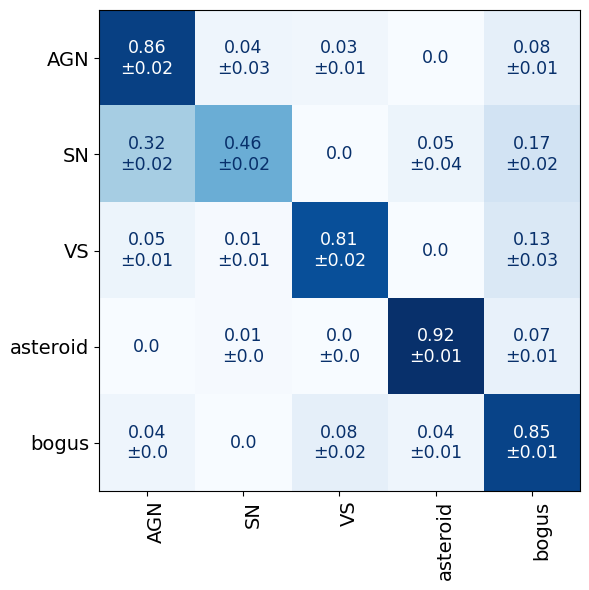

In [17]:
order_classes = ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
get_confusion_matrix(mean_cm_norm, std_cm_norm, order_classes)


      GRÁFICO DE MATRIZ DE CONFUSIÓN MIXTA
Texto: Recuento Promedio ± Std (No Normalizado)
Color: Proporción Promedio (Normalizado por fila/Recall)


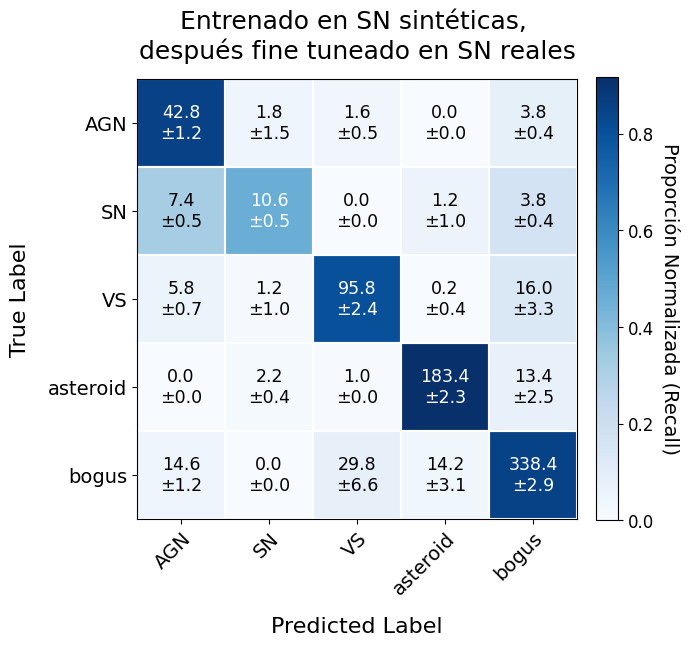

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn es excelente para heatmaps, pero nos quedaremos con plt para mantener tu estilo

# --- REEMPLAZA TU FUNCIÓN get_confusion_matrix CON ESTA ---
def plot_mixed_confusion_matrix(mean_text, std_text, mean_color, class_names, 
                                figsize=(7, 7), cmap='Blues', title='Entrenado en SN sintéticas, \ndespués fine tuneado en SN reales'):
    """
    Grafica una matriz de confusión con valores de texto no normalizados (media ± std)
    y colores de celda y barra de color basados en valores normalizados.

    Args:
        mean_text (np.array): Matriz promedio con los recuentos absolutos (no normalizada).
        std_text (np.array): Matriz de desviación estándar de los recuentos absolutos.
        mean_color (np.array): Matriz promedio normalizada (por fila, 'true') para el color.
        class_names (list): Lista de nombres de las clases para los ejes.
        figsize (tuple): Tamaño de la figura.
        cmap (str): Colormap a utilizar.
        title (str): Título del gráfico.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # 1. Usar la matriz NORMALIZADA (mean_color) para generar el heatmap (los colores)
    im = ax.imshow(mean_color, interpolation='nearest', cmap=cmap)

    # 2. Añadir la barra de color basada en la matriz NORMALIZADA
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Proporción Normalizada (Recall)", rotation=-90, va="bottom", size=14)
    cbar.ax.tick_params(labelsize=12)

    # 3. Iterar y añadir el texto usando las matrices NO NORMALIZADAS (mean_text y std_text)
    threshold = mean_color.max() / 2.  # Umbral para cambiar el color del texto (blanco/negro)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            # Formateamos el texto con los valores no normalizados
            text_val = f"{mean_text[i, j]:.1f}\n±{std_text[i, j]:.1f}"
            
            # El color del texto depende del color de fondo (que viene de la matriz normalizada)
            text_color = "white" if mean_color[i, j] > threshold else "black"
            
            ax.text(j, i, text_val, ha="center", va="center", color=text_color, fontsize=12.5)

    # --- Estilo y etiquetas (similar a tu código original) ---
    ax.set_title(title, fontsize=18, pad=15)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    
    ax.tick_params(axis='both', which='major', labelsize=14)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    ax.set_ylabel('True Label', fontsize=16)
    ax.set_xlabel('Predicted Label', fontsize=16)
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13

    # Añadir un borde a las celdas para mayor claridad
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='white', lw=1.5))


    fig.tight_layout()
    plt.show()

# Asegúrate de que 'class_names' es la variable correcta que contiene ['AGN', 'SN', ...]
# Tu código ya la define correctamente al inicio del bucle.
# La variable 'order_classes' que tenías es redundante si 'class_names' está bien definida.

if all_confusion_matrices:
    print("\n" + "="*50)
    print("      GRÁFICO DE MATRIZ DE CONFUSIÓN MIXTA")
    print("="*50)
    print("Texto: Recuento Promedio ± Std (No Normalizado)")
    print("Color: Proporción Promedio (Normalizado por fila/Recall)")
    
    plot_mixed_confusion_matrix(
        mean_text=mean_cm,          # Matriz NO normalizada para el texto
        std_text=std_cm,            # Matriz NO normalizada para el texto
        mean_color=mean_cm_norm,    # Matriz NORMALIZADA para el color
        class_names=class_names     # Los nombres de las clases en el orden correcto
    )
else:
    print("No hay datos para graficar la matriz de confusión.")


  MATRIZ DE CONFUSIÓN ESTIMADA PARA EL ENTORNO DE PRODUCCIÓN


,AGN,SN,VS,asteroid,bogus
AGN,59.9,2.5,2.2,0.0,5.3
SN,64.3,92.2,0.0,10.4,33.0
VS,350.9,72.6,5796.3,12.1,968.1
asteroid,0.0,33.0,15.0,2751.0,201.0
bogus,385.0,0.0,785.9,374.5,8924.6


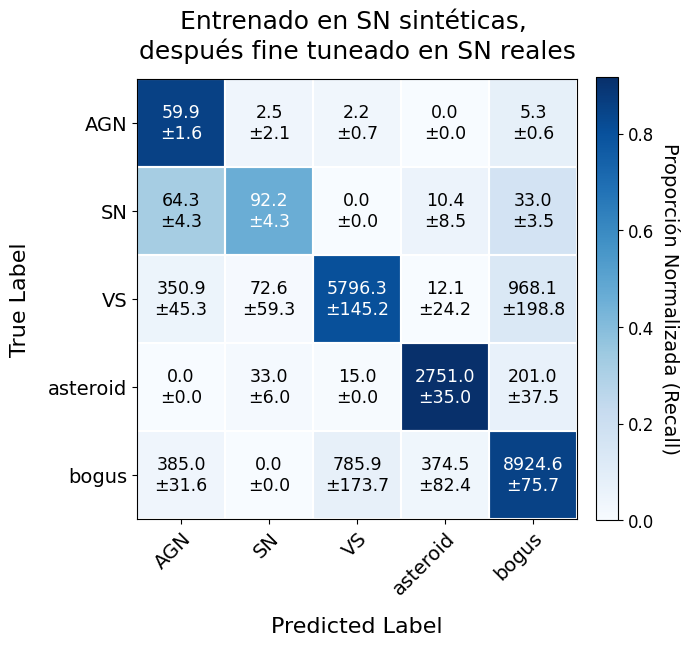

In [19]:
# 1. Definir la distribución de clases esperada en producción
prod_distribution = {
    'AGN': 70,
    'SN': 200,
    'VS': 7200,
    'asteroid': 3000,
    'bogus': 10470
}

# Asegurarnos de que el orden de las clases en el diccionario coincide con el de la matriz
# 'class_names' ya debería tener el orden correcto ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
prod_counts = np.array([prod_distribution[name] for name in class_names])

# 2. Calcular la matriz de confusión estimada para producción
# Usamos broadcasting de NumPy: (5x5 matrix) * (5x1 vector)
# Esto multiplica cada fila de la matriz por el elemento correspondiente del vector.
estimated_prod_cm = mean_cm_norm * prod_counts[:, np.newaxis]

# Para la desviación estándar, la propagación de errores es un poco más compleja,
# pero una aproximación razonable es escalar de la misma manera.
estimated_prod_std_cm = std_cm_norm * prod_counts[:, np.newaxis]


# 3. Mostrar y visualizar la nueva matriz de confusión estimada para producción
print("\n" + "="*60)
print("  MATRIZ DE CONFUSIÓN ESTIMADA PARA EL ENTORNO DE PRODUCCIÓN")
print("="*60)
estimated_prod_cm_df = pd.DataFrame(estimated_prod_cm, index=class_names, columns=class_names)
display(estimated_prod_cm_df.round(1))

# Visualizar la nueva matriz. 
# Nota: La normalizamos de nuevo para que los colores sigan representando el recall,
# pero el texto mostrará los números absolutos de producción.
estimated_prod_cm_norm_color = estimated_prod_cm / estimated_prod_cm.sum(axis=1, keepdims=True)

plot_mixed_confusion_matrix(
    mean_text=estimated_prod_cm,
    std_text=estimated_prod_std_cm,
    mean_color=estimated_prod_cm_norm_color, # Usamos la versión normalizada para el color
    class_names=class_names,
    title='Entrenado en SN sintéticas, \ndespués fine tuneado en SN reales'
)

In [20]:
class_map = {
    0: "AGN",
    1: "SN",
    2: "VS",
    3: "asteroid",
    4: "bogus"
}

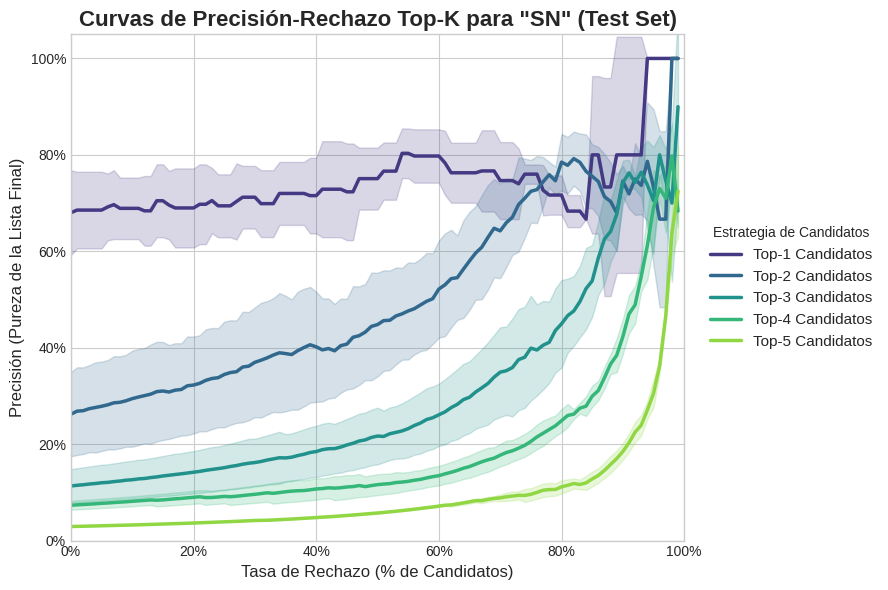

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


# --- Configuración del Análisis (sin cambios) ---
TARGET_CLASS_NAME = 'SN'
prob_columns = [f'prob_{name}' for name in class_map.values()]
class_map_inv = {v: k for k, v in class_map.items()}
target_class_id = class_map_inv[TARGET_CLASS_NAME]
prob_column_name = f'prob_{TARGET_CLASS_NAME}'

k_values = [1, 2, 3, 4, 5]
rejection_rates = np.linspace(0, 0.99, 100)

all_curves_data = {k: [] for k in k_values}

# --- Bucle principal por Fold (sin cambios) ---
for df_fold in all_predictions:
    probs = df_fold[prob_columns].to_numpy()
    sorted_class_indices = np.argsort(probs, axis=1)[:, ::-1]
    
    for k in k_values:
        top_k_indices = sorted_class_indices[:, :k]
        is_candidate = np.any(top_k_indices == target_class_id, axis=1)
        df_candidates_k = df_fold[is_candidate]
        
        if len(df_candidates_k) == 0:
            all_curves_data[k].append([np.nan] * len(rejection_rates))
            continue

        fold_precisions = []
        scores = df_candidates_k[prob_column_name].values
        
        for rate in rejection_rates:
            if len(scores) < 2:
                fold_precisions.append(np.nan)
                continue
                
            threshold = np.quantile(scores, rate)
            df_accepted = df_candidates_k[df_candidates_k[prob_column_name] >= threshold]
            
            if len(df_accepted) > 0:
                is_correct = (df_accepted['true_label'] == TARGET_CLASS_NAME)
                precision = is_correct.mean()
            else:
                precision = np.nan
                
            fold_precisions.append(precision)
        
        all_curves_data[k].append(fold_precisions)

# --- Agregación y Visualización (Con la leyenda afuera) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette("viridis", n_colors=len(k_values))

for i, k in enumerate(k_values):
    precisions_array = np.array(all_curves_data[k])
    
    mean_precisions = np.nanmean(precisions_array, axis=0)
    std_precisions = np.nanstd(precisions_array, axis=0)
    upper_bound = mean_precisions + std_precisions
    lower_bound = mean_precisions - std_precisions
    
    if not np.all(np.isnan(mean_precisions)):
        ax.plot(rejection_rates * 100, mean_precisions, 
                label=f'Top-{k} Candidatos', 
                color=palette[i], linewidth=2.5)
        
        ax.fill_between(rejection_rates * 100, lower_bound, upper_bound,
                        color=palette[i], alpha=0.2)

# Formato y etiquetas
ax.set_title(f'Curvas de Precisión-Rechazo Top-K para "{TARGET_CLASS_NAME}" (Test Set)', fontsize=16, weight='bold')
ax.set_xlabel('Tasa de Rechazo (% de Candidatos)', fontsize=12)
ax.set_ylabel('Precisión (Pureza de la Lista Final)', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))

# --- LÍNEA MODIFICADA PARA MOVER LA LEYENDA ---
ax.legend(title="Estrategia de Candidatos", fontsize=11, 
          bbox_to_anchor=(1.02, 0.5), loc='center left')
# ---------------------------------------------

# Ajusta el layout para asegurar que la leyenda quepa
plt.tight_layout()
plt.show()

Usando datos de ejemplo (mock) para 'tables'.



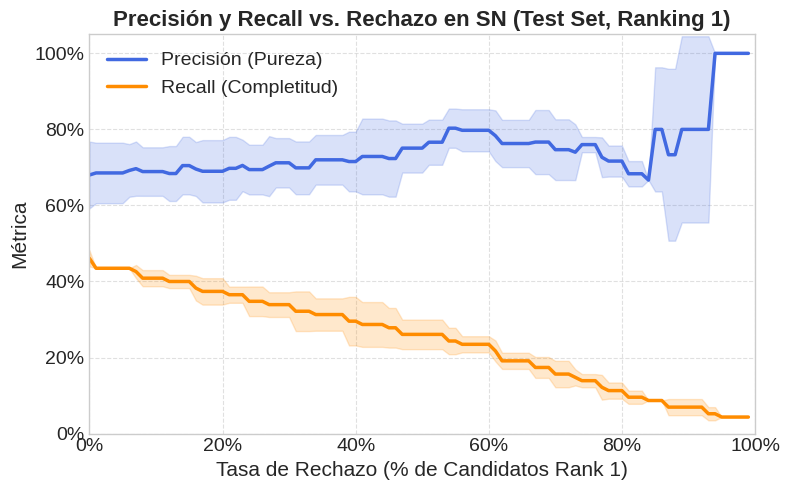

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Asumimos que 'all_predictions', 'tables' y 'class_map' ya existen ---
# (Usaré mocks para que el código sea ejecutable)
# ----------------- INICIO DEL MOCK DATA -----------------
def create_mock_predictions_sn(num_rows=800, num_folds=5): # Test Set Data
    mock_list = []
    labels = ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
    label_p = [0.1, 0.02, 0.15, 0.25, 0.48]
    for i in range(num_folds):
        df = pd.DataFrame()
        df['true_label'] = np.random.choice(labels, num_rows, p=label_p)
        probs = np.random.rand(num_rows, len(labels))
        # Make SN probs higher for real SNs and for predicted SNs
        true_sn_indices = df[df['true_label'] == 'SN'].index
        probs[true_sn_indices, 1] = np.clip(probs[true_sn_indices, 1] + 0.6, 0, 1)
        probs = probs / probs.sum(axis=1, keepdims=True)
        for idx, label_name in enumerate(labels):
             df[f'prob_{label_name}'] = probs[:, idx]
        df['predicted_label'] = pd.Index(labels)[np.argmax(probs, axis=1)]
        mock_list.append(df)
    return mock_list

def create_mock_tables(num_rows=20000): # Production Data
    df = pd.DataFrame()
    df['class_id'] = np.random.choice([0, 1, 2, 3, 4], num_rows, p=[0.05, 0.2, 0.3, 0.15, 0.3])
    df['ranking'] = np.random.randint(1, 6, num_rows)
    probs = np.random.beta(a=2, b=15, size=num_rows) + (1 - (df['ranking'] / 5)) * 0.3
    sn_indices = df[df['class_id'] == 0].index
    probs[sn_indices] = probs[sn_indices] + np.random.uniform(0, 0.4, size=len(sn_indices))
    df['probability'] = np.clip(probs, 0.01, 1.0)
    return df

class_map = {0: 'AGN', 1: 'SN', 2: 'VS', 3: 'asteroid', 4: 'bogus'}
if 'all_predictions' not in locals():
    print("Usando datos de ejemplo (mock) para 'all_predictions'.")
    all_predictions = create_mock_predictions_sn()
if 'tables' not in locals():
    print("Usando datos de ejemplo (mock) para 'tables'.\n")
    tables = create_mock_tables()
# ----------------- FIN DEL MOCK DATA -----------------


# --- Configuración del Análisis ---
TARGET_CLASS_NAME = 'SN'
SN_CLASS_ID = 1 # Asumo ID=1 para SN, cámbialo si es necesario
prob_column_name = f'prob_{TARGET_CLASS_NAME}'
rejection_rates = np.linspace(0, 0.99, 100)

# --- Creación de los Subplots ---
fig, ax1 = plt.subplots(figsize=(8, 5))
#ax1, ax2 = axes[0], axes[1]

# ==============================================================================
# GRÁFICO 1: ANÁLISIS EN EL CONJUNTO DE TEST (all_predictions)
# ==============================================================================
precisions_per_fold = []
recalls_per_fold = []

for df_fold in all_predictions:
    # El denominador del Recall: el número total de SN reales en este fold
    total_true_sns_in_fold = (df_fold['true_label'] == TARGET_CLASS_NAME).sum()

    # Filtramos para quedarnos solo con los candidatos de Ranking 1
    # En este dataset, Ranking 1 significa que la predicción fue SN
    candidates_rank1 = df_fold[df_fold['predicted_label'] == TARGET_CLASS_NAME]
    
    fold_precisions, fold_recalls = [], []
    scores = candidates_rank1[prob_column_name].values
    
    for rate in rejection_rates:
        if len(scores) < 2 or total_true_sns_in_fold == 0:
            fold_precisions.append(np.nan)
            fold_recalls.append(np.nan)
            continue
            
        threshold = np.quantile(scores, rate)
        df_accepted = candidates_rank1[candidates_rank1[prob_column_name] >= threshold]
        
        if len(df_accepted) > 0:
            # Precisión
            is_correct = (df_accepted['true_label'] == TARGET_CLASS_NAME)
            precision = is_correct.mean()
            # Recall
            true_positives = is_correct.sum()
            recall = true_positives / total_true_sns_in_fold
        else:
            precision, recall = np.nan, 0 # Si no aceptamos nada, la precisión es indefinida y el recall es 0
            
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        
    precisions_per_fold.append(fold_precisions)
    recalls_per_fold.append(fold_recalls)

# --- Agregación y Visualización para Test Set ---
# Precisión
mean_precisions = np.nanmean(precisions_per_fold, axis=0)
std_precisions = np.nanstd(precisions_per_fold, axis=0)
# Recall
mean_recalls = np.nanmean(recalls_per_fold, axis=0)
std_recalls = np.nanstd(recalls_per_fold, axis=0)

# Graficar Precisión
ax1.plot(rejection_rates * 100, mean_precisions, label='Precisión (Pureza)', color='royalblue', lw=2.5)
ax1.fill_between(rejection_rates * 100, mean_precisions - std_precisions, mean_precisions + std_precisions, color='royalblue', alpha=0.2)

# Graficar Recall
ax1.plot(rejection_rates * 100, mean_recalls, label='Recall (Completitud)', color='darkorange', lw=2.5)
ax1.fill_between(rejection_rates * 100, mean_recalls - std_recalls, mean_recalls + std_recalls, color='darkorange', alpha=0.2)
ax1.set_title('Precisión y Recall vs. Rechazo en SN (Test Set, Ranking 1)', fontsize=16, weight='bold')
ax1.set_xlabel('Tasa de Rechazo (% de Candidatos Rank 1)', fontsize=15)
ax1.set_ylabel('Métrica', fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=14)

ax1.set_ylim(0, 1.05)
ax1.set_xlim(0, 100)

ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))
ax1.legend(fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)

# ==============================================================================
# GRÁFICO 2: ANÁLISIS EN PRODUCCIÓN (tables)
# ==============================================================================
# Denominador del Recall: Total de SN reales en producción
total_true_sns_in_prod = (tables['class_id'] == SN_CLASS_ID).sum()

# Filtramos para candidatos de Ranking 1
prod_candidates_rank1 = tables[
    (tables.class_id == SN_CLASS_ID) & # Esto es para producción, así que asumimos que class_id es el tipo de objeto
    (tables.ranking == 1)
]

prod_precisions, prod_recalls = [], []
prod_scores = prod_candidates_rank1['probability'].values

for rate in rejection_rates:
    if len(prod_scores) < 2 or total_true_sns_in_prod == 0:
        prod_precisions.append(np.nan)
        prod_recalls.append(np.nan)
        continue

    threshold = np.quantile(prod_scores, rate)
    df_accepted = prod_candidates_rank1[prod_candidates_rank1.probability >= threshold]
    
    if len(df_accepted) > 0:
        # En producción, la precisión de los candidatos de Rank 1 es siempre 100% por definición
        precision = 1.0 
        true_positives = len(df_accepted)
        recall = true_positives / total_true_sns_in_prod
    else:
        precision, recall = np.nan, 0
    
    prod_precisions.append(precision)
    prod_recalls.append(recall)

# --- Visualización para Producción ---
#ax2.plot(rejection_rates * 100, prod_precisions, label='Precisión (Pureza)', color='royalblue', lw=2.5)
#ax2.plot(rejection_rates * 100, prod_recalls, label='Recall (Completitud)', color='darkorange', lw=2.5)
#ax2.set_title('Precisión y Recall vs. Rechazo (Producción, Ranking 1)', fontsize=14, weight='bold')
#ax2.set_xlabel('Tasa de Rechazo (% de Candidatos Rank 1)', fontsize=12)

# --- Formato Final para Ambos Gráficos ---
#for ax in axes:
#    ax.set_ylim(0, 1.05)
#    ax.set_xlim(0, 100)
#    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
#    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))
#    ax.legend()
#    ax.grid(True, linestyle='--', alpha=0.6)

#fig.suptitle('Análisis del Trade-off Precisión-Recall para Candidatos a SN de Ranking 1', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

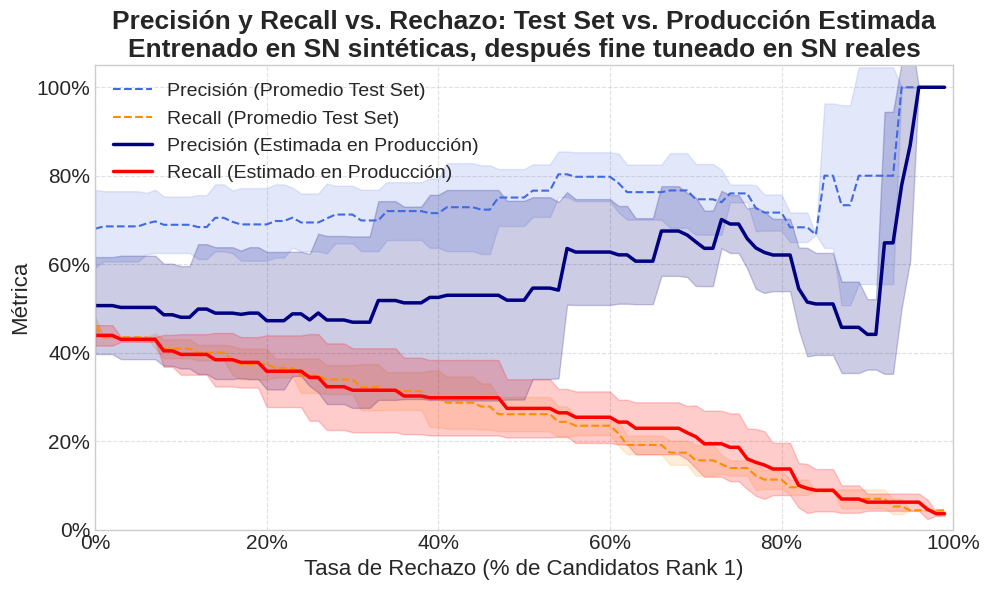

In [23]:
# --- CÓDIGO FINAL Y CORREGIDO PARA LA ESTIMACIÓN EN PRODUCCIÓN CON STD ---

# 1. Definir la distribución de clases de producción
prod_distribution = {
    'AGN': 70,
    'SN': 200,
    'VS': 7200,
    'asteroid': 3000,
    'bogus': 10470
}

# 2. Listas para guardar las curvas de cada simulación de fold
prod_sim_precisions_per_fold = []
prod_sim_recalls_per_fold = []

# 3. Iterar a través de las predicciones de cada fold individual
for df_fold in all_predictions:
    
    # --- a. Crear un DataFrame de producción simulado PARA ESTE FOLD ---
    prod_sim_df_list_fold = []
    for class_name, num_samples in prod_distribution.items():
        class_subset = df_fold[df_fold['true_label'] == class_name]
        
        if len(class_subset) == 0:
            # Si una clase no está en el test set de este fold, no podemos simularla.
            # Esto puede introducir algo de ruido, pero es la única opción.
            continue
        
        prod_sim_df_list_fold.append(
            class_subset.sample(n=num_samples, replace=True, random_state=42)
        )

    # Si por alguna razón no se pudo crear el df (ej. faltaban muchas clases)
    if not prod_sim_df_list_fold:
        continue
        
    prod_sim_df_fold = pd.concat(prod_sim_df_list_fold, ignore_index=True)
    
    # --- b. Calcular la curva de P-R para la simulación de este fold ---
    TARGET_CLASS_NAME = 'SN'
    prob_column_name = f'prob_{TARGET_CLASS_NAME}'
    rejection_rates = np.linspace(0, 0.99, 100)
    total_true_sns_in_prod_sim = prod_distribution.get(TARGET_CLASS_NAME, 0)

    candidates_rank1 = prod_sim_df_fold[prod_sim_df_fold['predicted_label'] == TARGET_CLASS_NAME]
    scores = candidates_rank1[prob_column_name].values
    
    fold_precisions, fold_recalls = [], []
    for rate in rejection_rates:
        if len(scores) < 2 or total_true_sns_in_prod_sim == 0:
            fold_precisions.append(np.nan)
            fold_recalls.append(np.nan)
            continue
            
        threshold = np.quantile(scores, rate)
        df_accepted = candidates_rank1[candidates_rank1[prob_column_name] >= threshold]
        
        if len(df_accepted) > 0:
            is_correct = (df_accepted['true_label'] == TARGET_CLASS_NAME)
            precision = is_correct.mean()
            true_positives = is_correct.sum()
            recall = true_positives / total_true_sns_in_prod_sim
        else:
            precision, recall = np.nan, 0
            
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        
    prod_sim_precisions_per_fold.append(fold_precisions)
    prod_sim_recalls_per_fold.append(fold_recalls)

# 4. Agregar los resultados de todas las simulaciones de folds
# Precisión
mean_prod_sim_precisions = np.nanmean(prod_sim_precisions_per_fold, axis=0)
std_prod_sim_precisions = np.nanstd(prod_sim_precisions_per_fold, axis=0)
# Recall
mean_prod_sim_recalls = np.nanmean(prod_sim_recalls_per_fold, axis=0)
std_prod_sim_recalls = np.nanstd(prod_sim_recalls_per_fold, axis=0)

# 5. Graficar todo junto
fig, ax = plt.subplots(figsize=(10, 6))

# Curvas originales del Test Set
ax.plot(rejection_rates * 100, mean_precisions, label='Precisión (Promedio Test Set)', color='royalblue', ls='--')
ax.fill_between(rejection_rates * 100, mean_precisions - std_precisions, mean_precisions + std_precisions, color='royalblue', alpha=0.15)
ax.plot(rejection_rates * 100, mean_recalls, label='Recall (Promedio Test Set)', color='darkorange', ls='--')
ax.fill_between(rejection_rates * 100, mean_recalls - std_recalls, mean_recalls + std_recalls, color='darkorange', alpha=0.15)

# Nuevas curvas estimadas para Producción con su desviación estándar
ax.plot(rejection_rates * 100, mean_prod_sim_precisions, label='Precisión (Estimada en Producción)', color='navy', lw=2.5)
ax.fill_between(rejection_rates * 100, mean_prod_sim_precisions - std_prod_sim_precisions, mean_prod_sim_precisions + std_prod_sim_precisions, color='navy', alpha=0.2)
ax.plot(rejection_rates * 100, mean_prod_sim_recalls, label='Recall (Estimado en Producción)', color='red', lw=2.5)
ax.fill_between(rejection_rates * 100, mean_prod_sim_recalls - std_prod_sim_recalls, mean_prod_sim_recalls + std_prod_sim_recalls, color='red', alpha=0.2)

# Estilo del gráfico
ax.set_title('Precisión y Recall vs. Rechazo: Test Set vs. Producción Estimada\nEntrenado en SN sintéticas, después fine tuneado en SN reales', fontsize=19, weight='bold')
ax.set_xlabel('Tasa de Rechazo (% de Candidatos Rank 1)', fontsize=16)
ax.set_ylabel('Métrica', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))
ax.legend(fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

In [24]:
import glob

path_real_stamps = glob.glob('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/processed/ts_stamps_v0.0.2_comm_4candmax/stamps/*.pkl')

df_real_all_stamps = []

for path in path_real_stamps:
    df_real_all_stamps.append(pd.read_pickle(path))

df_real_all_stamps = pd.concat(df_real_all_stamps)
df_real_all_stamps

,oid,measurement_id,flux_Science_data,flux_Science_header,flux_Template_data,flux_Template_header,flux_Difference_data,flux_Difference_header,variance_Science_data,variance_Science_header,variance_Template_data,variance_Template_header,variance_Difference_data,variance_Difference_header,mask_Science_data,mask_Science_header,mask_Template_data,mask_Template_header,mask_Difference_data,mask_Difference_header
0,169342391392665651,169368779404869680,"[[-11.43412, -61.157898, -36.767532, 2.3479912...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[19.970436, 9.456891, 13.70118, 1.8506378, 5....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-19.709507, -70.71258, -45.61192, -5.388886,...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[1350.7681, 1316.2396, 1328.7379, 1375.7206, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[48.75372, 48.6074, 44.92881, 53.182293, 40.7...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[1406.3743, 1370.4304, 1383.4205, 1432.3733, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.69...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.69...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
1,169342391392665651,169368781154418723,"[[12.617219, 24.45698, 35.47745, 10.133407, 73...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[9.981423, 20.141548, 23.992834, 33.55316, 59...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-17.836555, -11.826263, -7.5156693, -41.9118...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[172.93977, 179.61725, 185.36595, 171.49901, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[13.86152, 13.508177, 13.792195, 13.8862915, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[189.61496, 196.93031, 203.23215, 188.03621, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.58...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -2.02857206888...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.58...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
2,169342391396859977,169342391396859977,"[[20.201748, 8.987029, 20.140661, 5.541897, 2....","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[11.899033, 14.724549, 8.104676, 9.156919, 10...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[9.553257, -0.75593305, 11.6207695, -3.399367...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[113.74172, 110.11547, 114.21119, 107.290985,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[12.621083, 12.107674, 12.1881275, 14.158052,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[128.269, 124.173134, 128.77019, 121.12555, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.33...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.33...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
3,169342391461347756,169342391461347756,"[[7.650416, 16.770666, 41.501934, 16.376083, 2...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[21.86371, 25.689003, 24.45363, 27.604593, 15...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[-18.728577, -10.020834, 17.58616, -11.041704...","[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[118.146385, 123.34396, 135.7948, 123.88186, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[13.748417, 16.173056, 14.099533, 15.934614, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[133.68181, 139.71996, 153.50385, 140.3026, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...

In [25]:
merged_df = pd.merge(all_predictions[0], df_real_all_stamps, on=['oid', 'measurement_id'])
merged_df

,oid,measurement_id,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,...,variance_Template_data,variance_Template_header,variance_Difference_data,variance_Difference_header,mask_Science_data,mask_Science_header,mask_Template_data,mask_Template_header,mask_Difference_data,mask_Difference_header
0,169342391479697434,169342391479697434,4,4,bogus,bogus,0.465238,0.079728,0.000030,0.454875,...,"[[10.72114, 10.770189, 14.665173, 11.000376, 1...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[116.728714, 114.01459, 114.32161, 117.0606, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.47...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.47...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
1,169342391520592115,169342391520592115,4,4,bogus,bogus,0.989326,0.000118,0.000006,0.000347,...,"[[13.306577, 12.519216, 12.182476, 14.382535, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[117.868324, 113.57324, 110.44294, 114.6966, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.70...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.70...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
2,169342391522689127,169364381640949779,4,4,bogus,bogus,0.950906,0.001551,0.000015,0.042061,...,"[[40.186935, 38.75196, 40.72997, 40.181877, 42...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[636.47943, 638.712, 620.6105, 634.70197, 642...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.93...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 5.230466737590419e-12, -4.70528284...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.93...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
3,169342391608147991,169342391608147991,4,4,bogus,bogus,0.975581,0.000228,0.000027,0.000176,...,"[[14.556621, 14.651628, 15.640138, 12.231098, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[120.629974, 113.09305, 124.08029, 107.142365...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.24...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.24...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
4,169342391654809731,169342391654809731,4,0,bogus,AGN,0.782874,0.782874,0.014604,0.003202,...,"[[14.087751, 15.32384, 14.1205635, 14.625894, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[138.41882, 130.06357, 144.64929, 149.68568, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.98...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 9.98...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784,169562328094736421,169562328094736421,4,4,bogus,bogus,0.997039,0.000068,0.000001,0.000364,...,"[[401.3249, 377.98627, 402.1147, 384.16608, 40...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[3657.1235, 3643.9297, 3613.0073, 3684.5774, ...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0...","[XTENSION, BITPIX, NAXIS, NAXIS1, NAXIS2, PCOU...","[[-2.114689545858858e-11, 5.2053637570579076e-...","[XTENSION, BITPI

In [26]:
# --- 3. Filtrar los casos de interés ---

# A) PRECISION: Objetos que el modelo predijo como Supernova ('SN')
predicted_as_sn = merged_df[merged_df['predicted_label'] == 'SN'].copy()

# B) RECALL: Objetos que eran Supernova ('SN') pero el modelo falló
missed_sn = merged_df[(merged_df['true_label'] == 'SN') & (merged_df['predicted_label'] != 'SN')].copy()


# --- 4. Función para Graficar (MODIFICADA) ---
def plot_stamps(df, title_prefix):
    """
    Itera sobre un DataFrame filtrado y grafica las estampillas
    de forma compacta y sin ejes ni cuadrículas.
    """
    if df.empty:
        print(f"No se encontraron ejemplos para: '{title_prefix}'")
        return

    print(f"\n--- {title_prefix} ---")
    print(f"Mostrando {len(df)} ejemplos.")

    for index, row in df.iterrows():
        fig, axes = plt.subplots(1, 3, figsize=(7, 4))

        stamps_to_plot = {
            "Science": row['flux_Science_data'],
            "Template": row['flux_Template_data'],
            "Difference": row['flux_Difference_data']
        }
        
        # Iteramos para aplicar los cambios a cada subplot
        for i, (title, data) in enumerate(stamps_to_plot.items()):
            ax = axes[i]
            im = ax.imshow(data, cmap='viridis')
            ax.set_title(title)

            #fig.colorbar(im, ax=ax, shrink=0.4, aspect=7)
            
            ax.grid(False)
            #ax.set_xticks([])
            #ax.set_yticks([])

        main_title = (
            f"oid: {row['oid']} | measurement_id: {row['measurement_id']}\n"
            f"Etiqueta Real: '{row['true_label']}' | Predicción del Modelo: '{row['predicted_label']}'"
        )
        fig.suptitle(main_title, fontsize=14, y=0.87) # Ajuste de 'y' para el nuevo tamaño
        
        plt.tight_layout() # Ajuste para que el suptitle no se solape
        plt.show()



--- Análisis de Precisión: Objetos Predichos como Supernova ---
Mostrando 14 ejemplos.


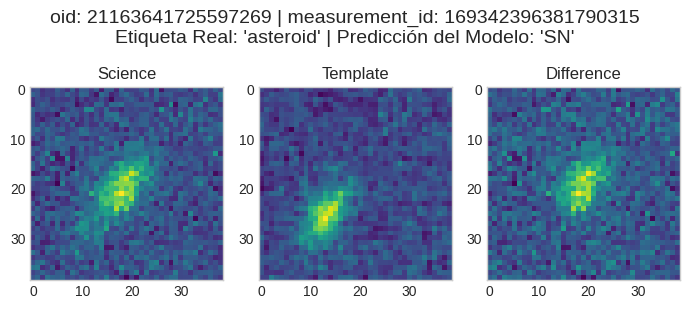

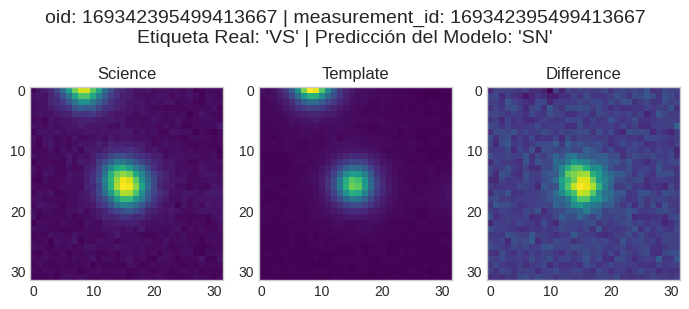

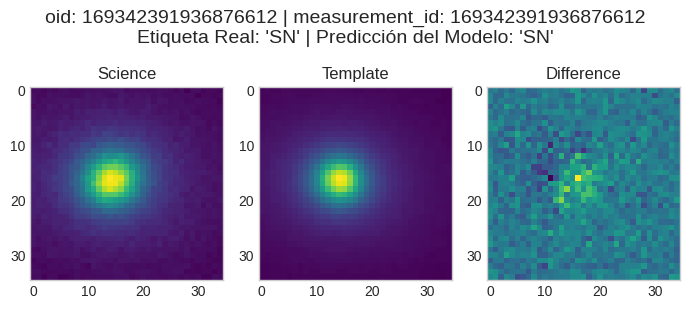

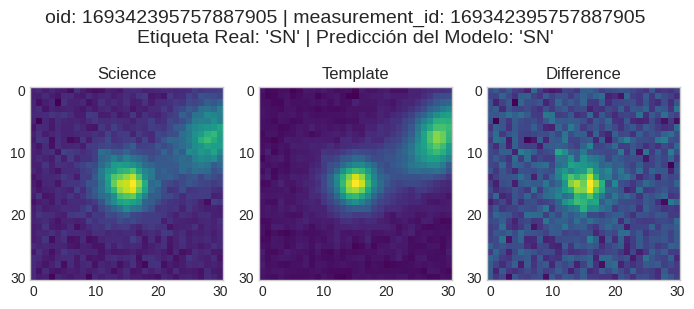

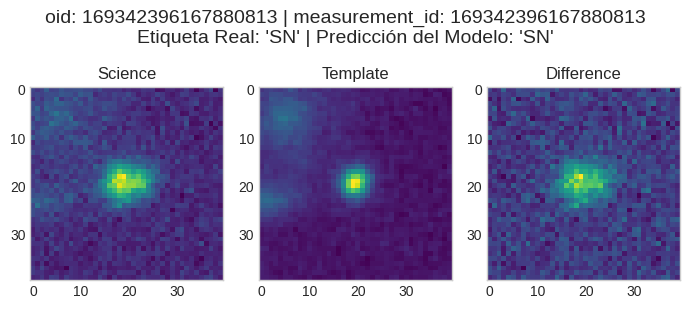

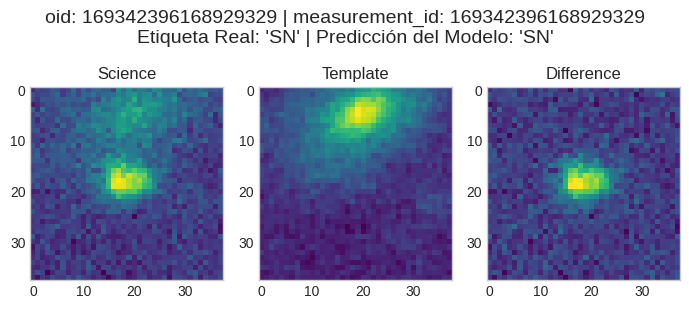

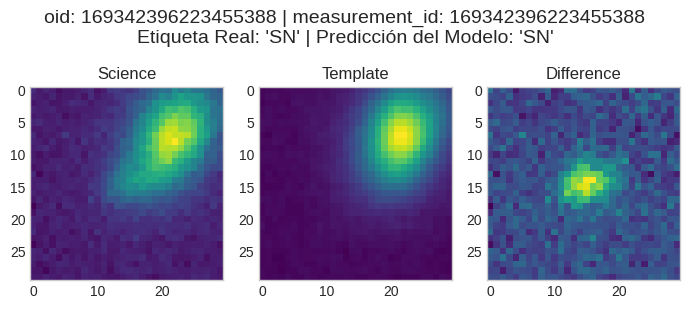

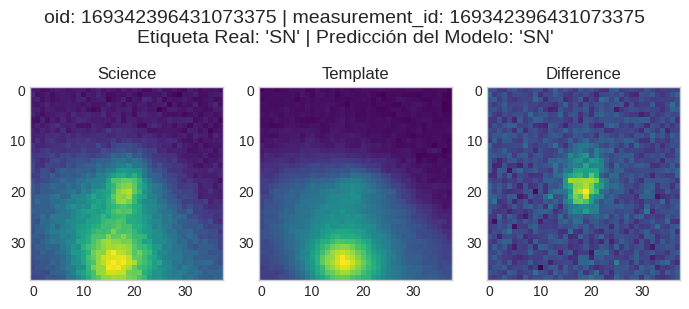

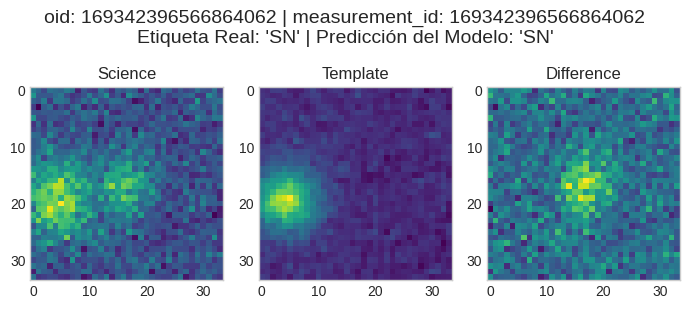

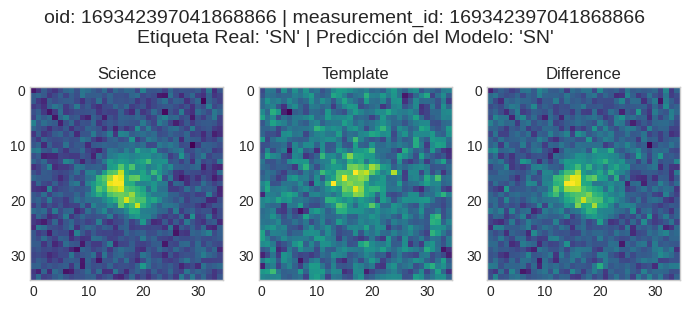

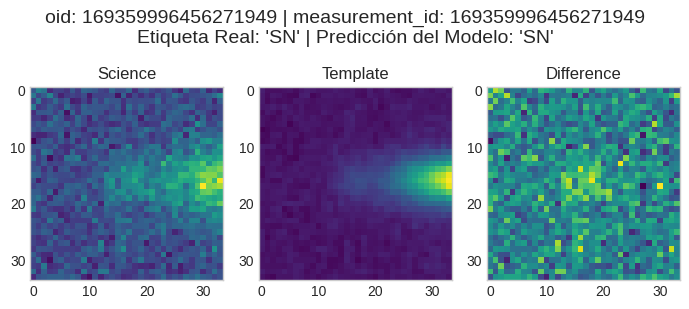

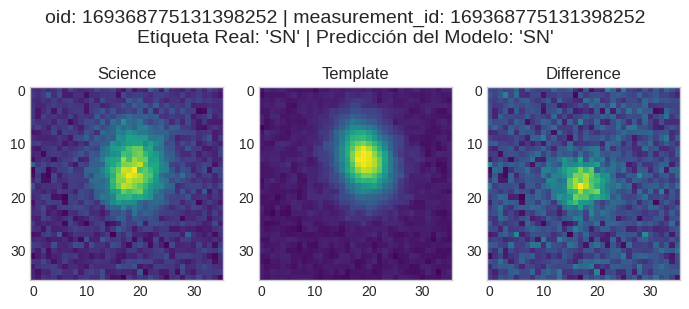

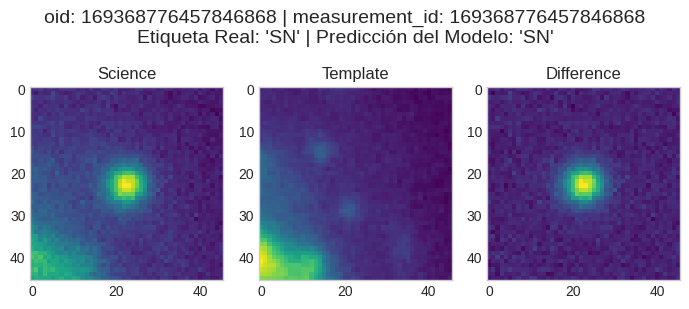

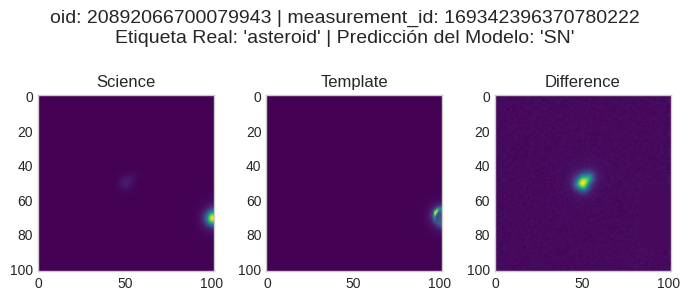

In [27]:
# Visualización para la PRECISIÓN
plot_stamps(
    predicted_as_sn, 
    "Análisis de Precisión: Objetos Predichos como Supernova"
)


--- Análisis de Recall: Supernovas Reales que el Modelo no Detectó ---
Mostrando 12 ejemplos.


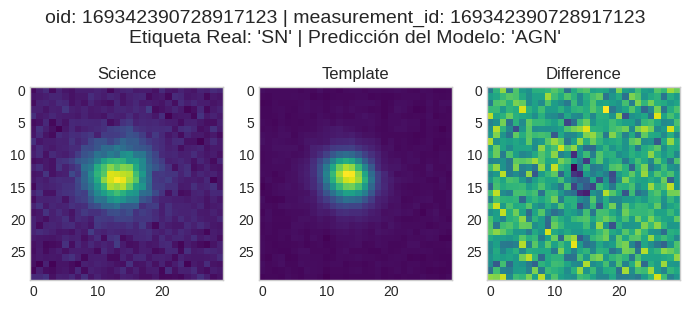

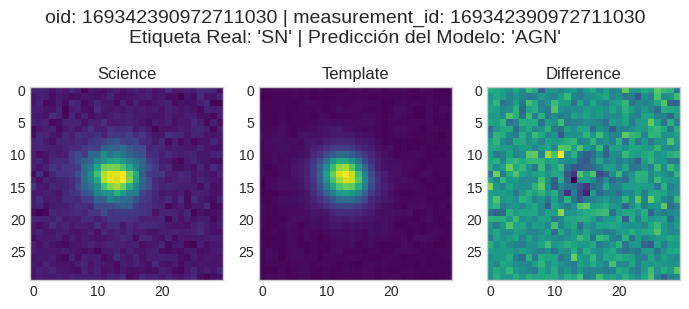

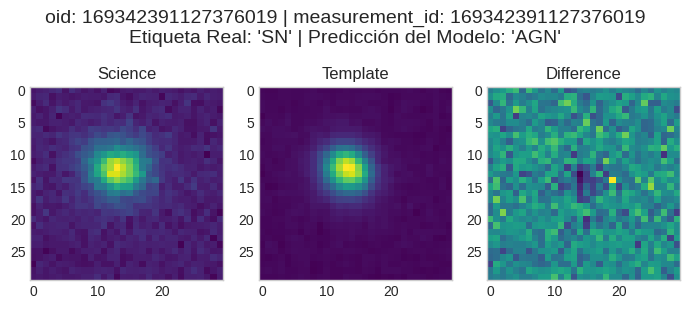

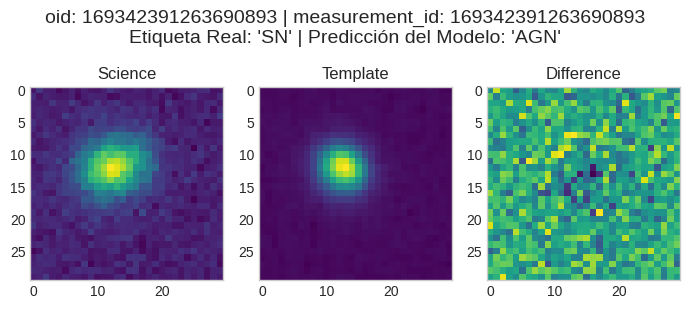

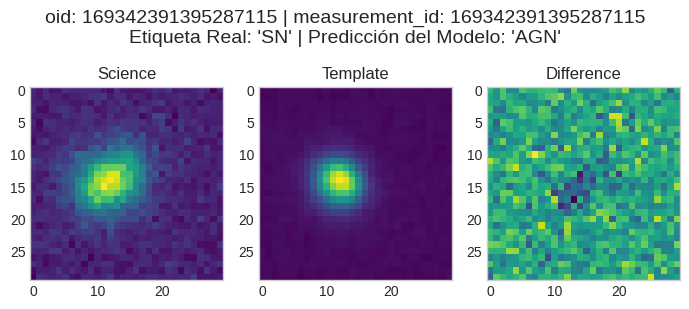

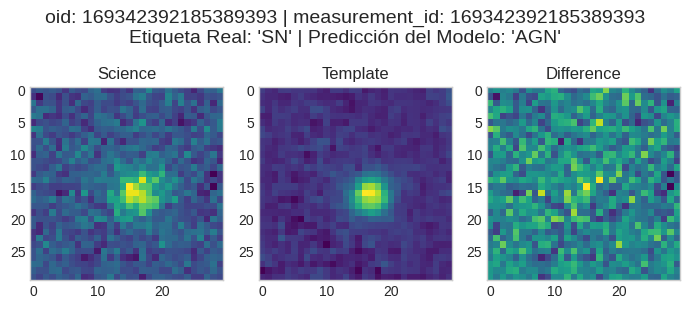

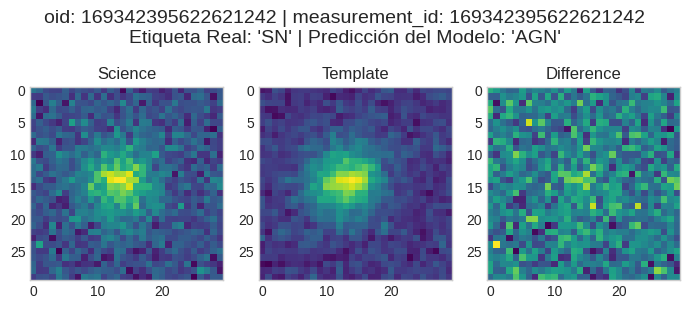

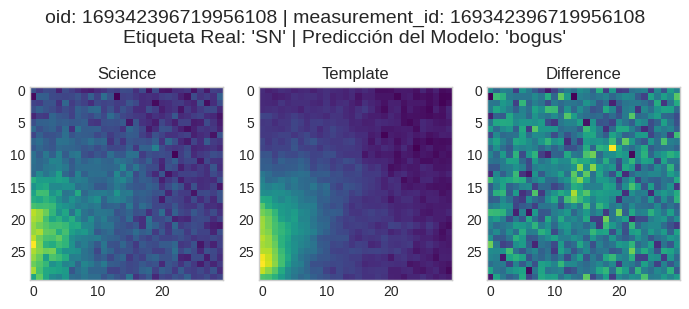

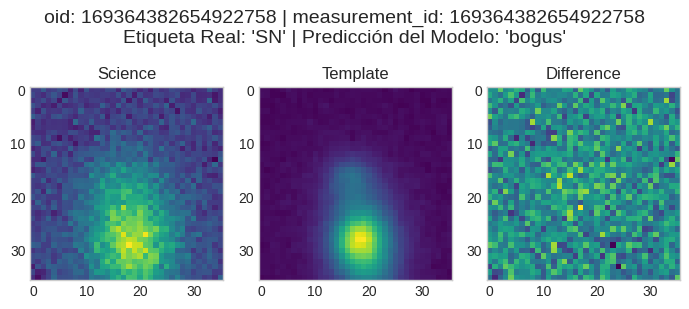

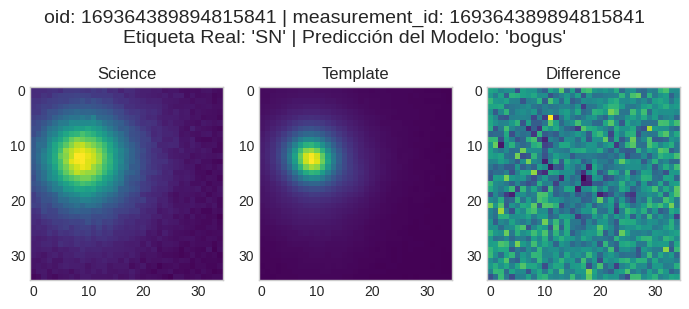

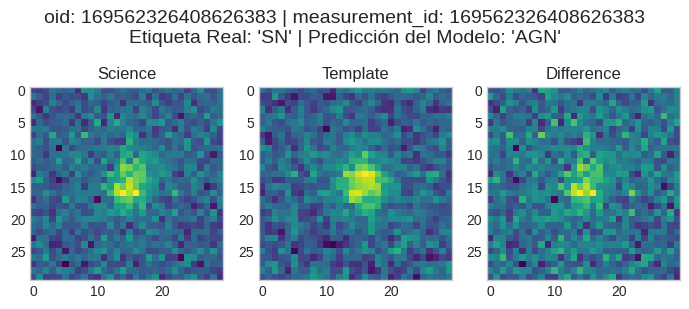

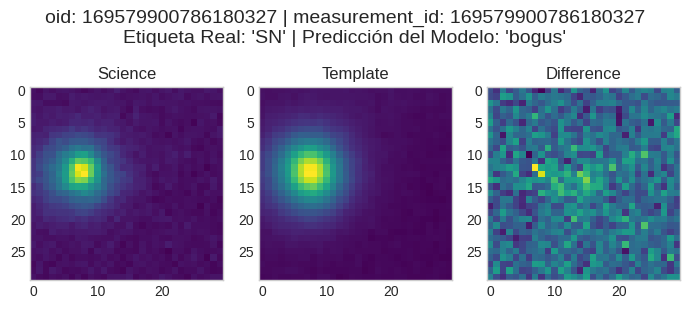

In [28]:
# Visualización para el RECALL
plot_stamps(
    missed_sn, 
    "Análisis de Recall: Supernovas Reales que el Modelo no Detectó"
)

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Asegúrate de que df_real_all_stamps esté definido con las columnas oid y measurement_id
# y que all_predictions sea una lista de DataFrames de predicciones.

# 1. Definir la carpeta base para guardar los plots
OUTPUT_DIR = 'sinteticas_finetuneado_en_reales_plots_por_fold'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 4. Función para Graficar (MODIFICADA para guardar) ---
def plot_stamps(df, title_prefix, output_folder, max_plots=5):
    """
    Itera sobre un DataFrame filtrado y grafica las estampillas
    guardándolas en la carpeta especificada.
    
    Args:
        df (pd.DataFrame): DataFrame con las estampillas.
        title_prefix (str): Prefijo del título para los logs.
        output_folder (str): Ruta de la carpeta donde guardar los plots.
        max_plots (int): Número máximo de plots a guardar para evitar sobrecarga.
    """
    if df.empty:
        print(f"No se encontraron ejemplos para: '{title_prefix}'")
        return

    print(f"\n--- {title_prefix} ---")
    num_to_plot = min(len(df), max_plots)
    print(f"Mostrando y guardando {num_to_plot} ejemplos de {len(df)} encontrados.")

    # Asegurarse de que la carpeta de salida exista
    os.makedirs(output_folder, exist_ok=True)
    
    # Solo graficar un número limitado de ejemplos
    for index, row in df.head(max_plots).iterrows():
        fig, axes = plt.subplots(1, 3, figsize=(7, 4))

        stamps_to_plot = {
            "Science": row['flux_Science_data'],
            "Template": row['flux_Template_data'],
            "Difference": row['flux_Difference_data']
        }
        
        # Iteramos para aplicar los cambios a cada subplot
        for i, (title, data) in enumerate(stamps_to_plot.items()):
            ax = axes[i]
            # Usamos 'viridis' si no hay otra información de cmap
            im = ax.imshow(data, cmap='viridis') 
            ax.set_title(title)
            
            ax.grid(False)
            #ax.set_xticks([])
            #ax.set_yticks([])

        true_label = row['true_label'].replace('/', '_')
        predicted_label = row['predicted_label'].replace('/', '_')
        
        main_title = (
            f"oid: {row['oid']} | measurement_id: {row['measurement_id']}\n"
            f"Etiqueta Real: '{true_label}' | Predicción del Modelo: '{predicted_label}'"
        )
        fig.suptitle(main_title, fontsize=14, y=0.87)
        
        plt.tight_layout()
        
        # --- Guardar el plot en la carpeta del fold ---
        
        # Generar un nombre de archivo descriptivo
        file_name_type = title_prefix.split(':')[0].replace(' ', '_').lower()
        file_name = (
            f"{file_name_type}_oid_{row['oid']}_mid_{row['measurement_id']}.png"
        )
        save_path = os.path.join(output_folder, file_name)
        
        plt.savefig(save_path)
        plt.close(fig) # Cierra la figura para liberar memoria
        print(f"Guardado: {save_path}")


# 2. Iterar sobre todos los folds
for fold_index, fold_predictions_df in enumerate(all_predictions):
    
    print(f"\n=======================================================")
    print(f"Procesando Fold {fold_index}")
    print(f"=======================================================")
    
    # 3. Crear la ruta de salida específica para este fold
    fold_output_folder = os.path.join(OUTPUT_DIR, f'fold_{fold_index}')
    os.makedirs(fold_output_folder, exist_ok=True)

    # 4. Combinar datos del fold con las estampillas
    merged_df = pd.merge(fold_predictions_df, df_real_all_stamps, on=['oid', 'measurement_id'])

    # A) PRECISION: Objetos predichos como Supernova ('SN')
    predicted_as_sn = merged_df[merged_df['predicted_label'] == 'SN'].copy()

    # B) RECALL: Objetos que eran Supernova ('SN') pero el modelo falló (Falsos Negativos)
    missed_sn = merged_df[(merged_df['true_label'] == 'SN') & (merged_df['predicted_label'] != 'SN')].copy()

    
    # 5. Visualización para la PRECISIÓN (True Positives + False Positives)
    # Guardamos los ejemplos de los objetos predichos como SN
    plot_stamps(
        predicted_as_sn, 
        "Precision: Objetos Predichos como Supernova",
        fold_output_folder
    )

    # 6. Visualización para el RECALL (False Negatives)
    # Guardamos los ejemplos de las Supernovas que el modelo falló
    plot_stamps(
        missed_sn, 
        "Recall: Supernovas Reales que el Modelo no Detectó",
        fold_output_folder
    )

print("\nProceso de guardado completado.")


Procesando Fold 0

--- Precision: Objetos Predichos como Supernova ---
Mostrando y guardando 5 ejemplos de 14 encontrados.
Guardado: sinteticas_finetuneado_en_reales_plots_por_fold/fold_0/precision_oid_21163641725597269_mid_169342396381790315.png
Guardado: sinteticas_finetuneado_en_reales_plots_por_fold/fold_0/precision_oid_169342395499413667_mid_169342395499413667.png
Guardado: sinteticas_finetuneado_en_reales_plots_por_fold/fold_0/precision_oid_169342391936876612_mid_169342391936876612.png
Guardado: sinteticas_finetuneado_en_reales_plots_por_fold/fold_0/precision_oid_169342395757887905_mid_169342395757887905.png
Guardado: sinteticas_finetuneado_en_reales_plots_por_fold/fold_0/precision_oid_169342396167880813_mid_169342396167880813.png

--- Recall: Supernovas Reales que el Modelo no Detectó ---
Mostrando y guardando 5 ejemplos de 12 encontrados.
Guardado: sinteticas_finetuneado_en_reales_plots_por_fold/fold_0/recall_oid_169342390728917123_mid_169342390728917123.png
Guardado: sintetic

In [30]:
synthetic_total_SN = pd.read_pickle('/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin/data/simulated_data/synthetic_total_SN.pkl')
synthetic_total_SN = synthetic_total_SN[['synth_file_path', 'SN_ellip_dist', 'band']]
synthetic_total_SN

,synth_file_path,SN_ellip_dist,band
0,611256378312376542_z_2024120800360_8_592913913...,0.33,z
1,609780833707896898_g_2024112900266_0_650018217...,0.88,g
2,611255691117605475_r_2024113000163_3_614437609...,0.74,r
3,611255622398132035_i_2024120300157_8_648363383...,0.90,i
4,609788117972430021_i_2024111900089_8_650018148...,0.57,i
...,...,...,...
4494,609788117972430021_r_2024112700181_2_611255003...,0.21,r
4495,611253698252783373_y_2024112000234_4_592914119...,1.00,y
4496,611253560813832654_z_2024120900325_6_611254522...,0.30,z
4497,609781589622141692_i_2024120300155_0_648367507...,1.00,i


Iniciando cálculo de Matrices de Confusión para datos SIMULADOS...

Calculando CM Promedio a partir de 5 folds SIMULADOS.


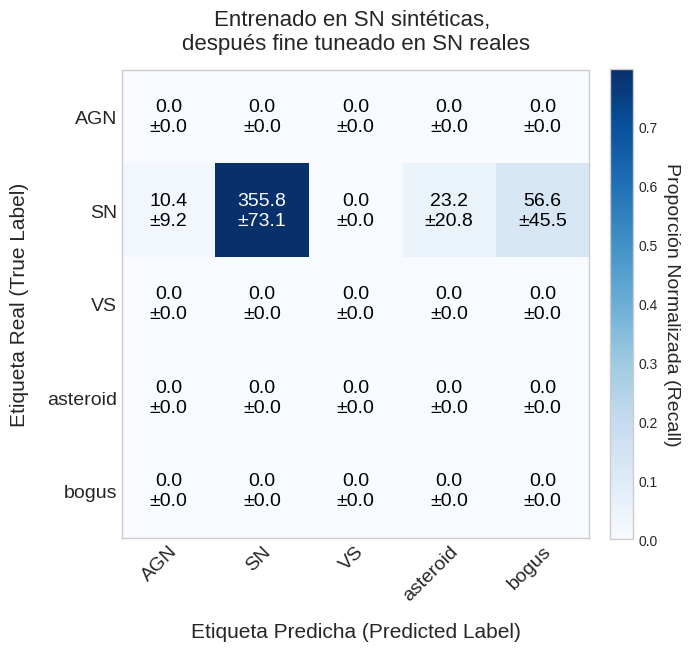

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Datos proporcionados (Asegúrate de que estas variables estén disponibles)
class_map = {
    0: "AGN",
    1: "SN",
    2: "VS",
    3: "asteroid",
    4: "bogus"
}
# La variable all_predictions_sim debe contener la lista de DataFrames simulados por fold.
# Ejemplo: all_predictions_sim = [df_fold_0, df_fold_1, ...]

# 2. Definir las etiquetas en el orden deseado
LABELS = [class_map[i] for i in sorted(class_map.keys())]
N_CLASSES = len(LABELS)


# 3. Función de Ploteo de Matriz de Confusión (Formato Mixto - SIN CUADRÍCULAS)
def plot_mixed_confusion_matrix(mean_text, std_text, mean_color, class_names, 
                                figsize=(7, 7), cmap='Blues', title='Matriz de Confusión Promedio (Datos Simulados)'):
    """
    Grafica una matriz de confusión con el formato deseado (texto μ ± σ y color normalizado),
    eliminando las cuadrículas interiores y ajustando el estilo.
    """
    N_CLASSES = len(class_names)
    fig, ax = plt.subplots(figsize=figsize)
    
    # 1. Usar la matriz NORMALIZADA (mean_color) para generar el heatmap (los colores)
    im = ax.imshow(mean_color, interpolation='nearest', cmap=cmap)

    # 2. Añadir la barra de color basada en la matriz NORMALIZADA
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Proporción Normalizada (Recall)", rotation=-90, va="bottom", size=14)
    cbar.ax.tick_params(labelsize=10)

    # 3. Iterar y añadir el texto (μ ± σ)
    threshold = mean_color.max() / 2.
    
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            # Recuentos absolutos con un decimal
            text_val = f"{mean_text[i, j]:.1f}\n±{std_text[i, j]:.1f}"
            text_color = "white" if mean_color[i, j] > threshold else "black"
            
            ax.text(j, i, text_val, ha="center", va="center", color=text_color, fontsize=14)

    # --- Estilo y etiquetas ---
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_xticks(np.arange(N_CLASSES))
    ax.set_yticks(np.arange(N_CLASSES))
    
    ax.set_xticklabels(class_names, fontsize=14)
    ax.set_yticklabels(class_names, fontsize=14)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    ax.set_ylabel('Etiqueta Real (True Label)', fontsize=15)
    ax.set_xlabel('Etiqueta Predicha (Predicted Label)', fontsize=15)
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13

    # ELIMINAR CUADRÍCULAS/BORDES
    ax.tick_params(which='both', width=0)
    ax.grid(False)

    fig.tight_layout()
    plt.show()


# 4. CALCULAR MATRICES DE CONFUSIÓN SOLO PARA DATOS SIMULADOS
simulated_cms = []

print("Iniciando cálculo de Matrices de Confusión para datos SIMULADOS...")

for fold_index, fold_df in enumerate(all_predictions_sim):
    
    y_true = fold_df['true_label']
    y_pred = fold_df['predicted_label']
    
    if len(y_true) == 0:
        print(f"Advertencia: No hay datos en el Fold {fold_index} simulado. Saltando.")
        continue

    # Calculamos la Matriz de Confusión Absoluta
    try:
        cm_abs = confusion_matrix(y_true, y_pred, labels=LABELS)
        simulated_cms.append(cm_abs)
    except ValueError as e:
        print(f"Error al calcular CM en Fold {fold_index} simulado: {e}")
        continue

# 5. AGREGACIÓN Y GRÁFICO
if not simulated_cms:
    print("No se pudo calcular ninguna matriz de confusión a partir de all_predictions_sim.")
else:
    
    # 5.1 Agregación de Resultados (Media y Desviación Estándar)
    all_cm_array = np.array(simulated_cms)
    
    # Media y Desviación Estándar de recuentos ABSOLUTOS
    mean_cm = np.mean(all_cm_array, axis=0)
    std_cm = np.std(all_cm_array, axis=0)
    
    print("\n" + "="*50)
    print(f"Calculando CM Promedio a partir de {len(simulated_cms)} folds SIMULADOS.")
    print("="*50)

    # 5.2 Normalización (para los COLORES)
    row_sums = mean_cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1 
    mean_cm_norm = mean_cm / row_sums

    # 5.3 Graficar la Matriz de Confusión Mixta
    plot_mixed_confusion_matrix(
        mean_text=mean_cm,
        std_text=std_cm,
        mean_color=mean_cm_norm,
        class_names=LABELS,
        title='Entrenado en SN sintéticas, \ndespués fine tuneado en SN reales'
    )

/tmp/ipykernel_2665764/1447363475.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_radius = plot_data_radius.groupby('radius_bin')['is_correct'].agg(['mean', 'std', 'count']).reset_index()
/tmp/ipykernel_2665764/1447363475.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_radius = sns.barplot(


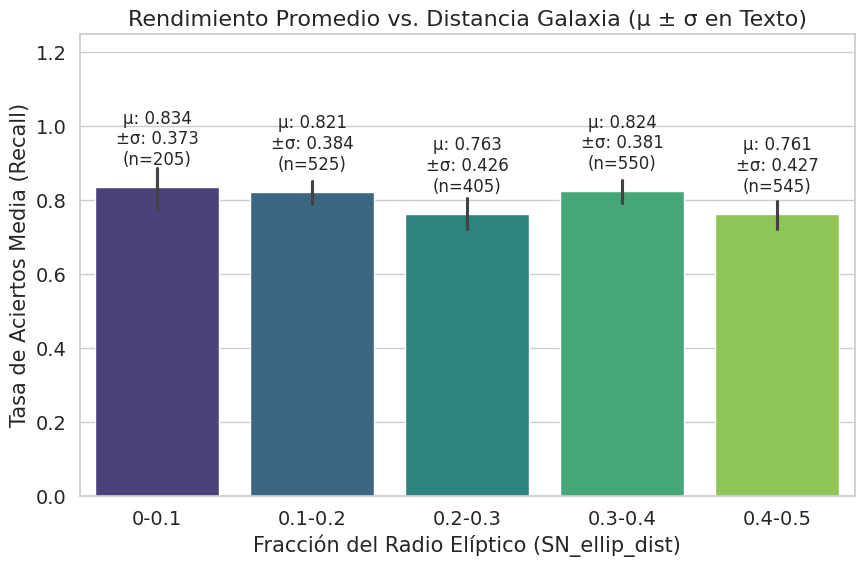

/tmp/ipykernel_2665764/1447363475.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_band = sns.barplot(


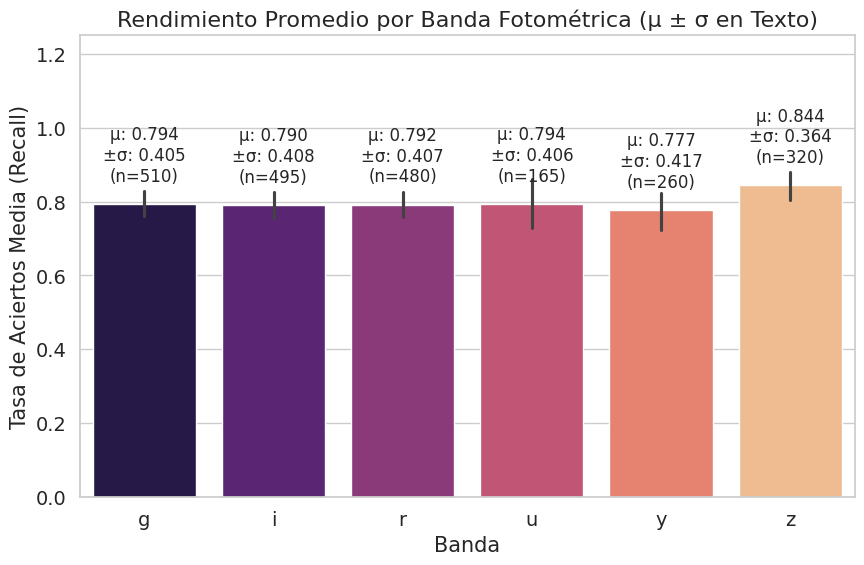

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración inicial
sns.set_theme(style="whitegrid")

# --- 1. CONCATENAR PREDICCIONES DE TODOS LOS FOLDS ---
if not isinstance(all_predictions_sim, list) or not all_predictions_sim:
    print("Error: 'all_predictions_sim' debe ser una lista de DataFrames no vacía.")
    exit()
    
all_sim_predictions_df = pd.concat(all_predictions_sim, ignore_index=True)

# --- 2. MERGEAR CON METADATOS SIMULADOS ---
# Asumimos que synthetic_total_SN tiene las columnas necesarias
merged_sim_df = pd.merge(
    all_sim_predictions_df,
    synthetic_total_SN,
    left_on='measurement_id',
    right_on='synth_file_path',
    how='inner'
)

# Preparación de la variable de acierto
merged_sim_df['is_correct'] = (merged_sim_df['predicted_label'] == 'SN').astype(int)


# --- FUNCIÓN AUXILIAR PARA ANOTAR MEDIA Y STD ---
def annotate_mu_sigma(ax, stats_df, x_col, order=None):
    """
    Añade anotaciones de Media (μ) ± Desviación Estándar (σ) a un barplot.
    """
    
    # Asegurar el orden del DataFrame de estadísticas
    if order is not None:
        stats_df = stats_df.set_index(x_col).loc[order].reset_index()

    for i, p in enumerate(ax.patches):
        if i < len(stats_df):
            mu = stats_df.iloc[i]['mean']
            sigma = stats_df.iloc[i]['std']
            n = stats_df.iloc[i]['count']
            
            # Formato de texto: Media ± Std (en proporción) y n
            text_annotation = f'μ: {mu:.3f}\n±σ: {sigma:.3f}\n(n={n})'
            
            # El texto se coloca en la parte superior de la barra
            ax.annotate(
                text_annotation,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 35), # Pequeño desplazamiento hacia arriba
                textcoords='offset points',
                fontsize=12
            )


# =========================================================================
# A) GRÁFICO 1: ANÁLISIS por FRACCIÓN de RADIO (Solo Texto μ ± σ)
# =========================================================================

radius_bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
radius_labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5']

merged_sim_df['radius_bin'] = pd.cut(
    merged_sim_df['SN_ellip_dist'],
    bins=radius_bins,
    labels=radius_labels,
    right=True,
    include_lowest=True
)

plot_data_radius = merged_sim_df.dropna(subset=['radius_bin'])

# Calcular estadísticas para el texto
stats_radius = plot_data_radius.groupby('radius_bin')['is_correct'].agg(['mean', 'std', 'count']).reset_index()

plt.figure(figsize=(10, 6))
ax_radius = sns.barplot(
    data=plot_data_radius,
    x='radius_bin',
    y='is_correct',
    palette='viridis',
    # !!! SIN errorbar: solo la media se grafica
    order=radius_labels
)

ax_radius.tick_params(axis='both', which='major', labelsize=14) # Aumentado a 12

# Añadir etiquetas de Media ± Std
annotate_mu_sigma(ax_radius, stats_radius, 'radius_bin', order=radius_labels)

plt.title('Rendimiento Promedio vs. Distancia Galaxia (μ ± σ en Texto)', fontsize=16)
plt.xlabel('Fracción del Radio Elíptico (SN_ellip_dist)', fontsize=15)
plt.ylabel('Tasa de Aciertos Media (Recall)', fontsize=15)
plt.ylim(0, 1.25)
plt.show()


# =========================================================================
# B) GRÁFICO 2: ANÁLISIS por BANDA FOTOMÉTRICA (Solo Texto μ ± σ)
# =========================================================================

band_order = sorted(merged_sim_df['band'].unique())

# Calcular estadísticas para el texto
stats_band = merged_sim_df.groupby('band')['is_correct'].agg(['mean', 'std', 'count']).reset_index()

plt.figure(figsize=(10, 6))
ax_band = sns.barplot(
    data=merged_sim_df,
    x='band',
    y='is_correct',
    palette='magma',
    # !!! SIN errorbar: solo la media se grafica
    order=band_order
)

ax_band.tick_params(axis='both', which='major', labelsize=14) # Aumentado a 12

# Añadir etiquetas de Media ± Std
annotate_mu_sigma(ax_band, stats_band, 'band', order=band_order)

plt.title('Rendimiento Promedio por Banda Fotométrica (μ ± σ en Texto)', fontsize=16)
plt.xlabel('Banda', fontsize=15)
plt.ylabel('Tasa de Aciertos Media (Recall)', fontsize=15)
plt.ylim(0, 1.25)
plt.show()

In [33]:
merged_sim_df = pd.merge(
    all_predictions_sim[0],
    synthetic_total_SN,
    left_on='measurement_id',
    right_on='synth_file_path',
    how='inner' # Nos quedamos solo con las filas que están en ambos archivos
)

merged_sim_df

,oid,measurement_id,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,prob_asteroid,prob_bogus,synth_file_path,SN_ellip_dist,band
0,609780833707896898,609780833707896898_g_2024112900266_0_609782139...,1,1,SN,SN,0.998847,0.000933,0.998847,0.000089,0.000110,2.132536e-05,609780833707896898_g_2024112900266_0_609782139...,0.06,g
1,609780833707896898,609780833707896898_z_2024120900320_0_609789629...,1,1,SN,SN,0.999950,0.000011,0.999950,0.000001,0.000036,9.955862e-07,609780833707896898_z_2024120900320_0_609789629...,0.06,z
2,609780833707896898,609780833707896898_g_2024112900266_0_592913981...,1,1,SN,SN,0.996012,0.002554,0.996012,0.000072,0.000157,1.204948e-03,609780833707896898_g_2024112900266_0_592913981...,0.12,g
3,609780833707896898,609780833707896898_z_2024120900320_0_611254591...,1,1,SN,SN,0.562225,0.000143,0.562225,0.000463,0.088021,3.491485e-01,609780833707896898_z_2024120900320_0_611254591...,0.12,z
4,609780833707896898,609780833707896898_z_2024120900320_0_648366407...,1,1,SN,SN,0.995796,0.003998,0.995796,0.000130,0.000057,2.005221e-05,609780833707896898_z_2024120900320_0_648366407...,0.19,z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,611257134226611503,611257134226611503_i_2024112900276_2_648367026...,1,1,SN,SN,0.999710,0.000175,0.999710,0.000038,0.000026,5.064372e-05,611257134226611503_i_2024112900276_2_648367026...,0.37,i
442,611257134226611503,611257134226611503_u_2024120100160_0_614439120...,1,1,SN,SN,0.997583,0.000122,0.997583,0.000038,0.000135,2.122416e-03,611257134226611503_u_2024120100160_0_614439120...,0.40,u
443,611257134226611503,611257134226611503_i_2024112900276_2_648367026...,1,1,SN,SN,0.999626,0.000231,0.999626,0.000025,0.000116,1.920067e-06,611257134226611503_i_2024112900276_2_648367026...,0.42,i
444,611257134226611503,611257134226611503_i_2024112900276_2_648372111...,1,1,SN,SN,0.999889,0.000022,0.999889,0.000003,0.000085,1.445232e-06,611257134226611503_i_2024112900276_2_648372111...,0.47,i


/tmp/ipykernel_2665764/3162717713.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


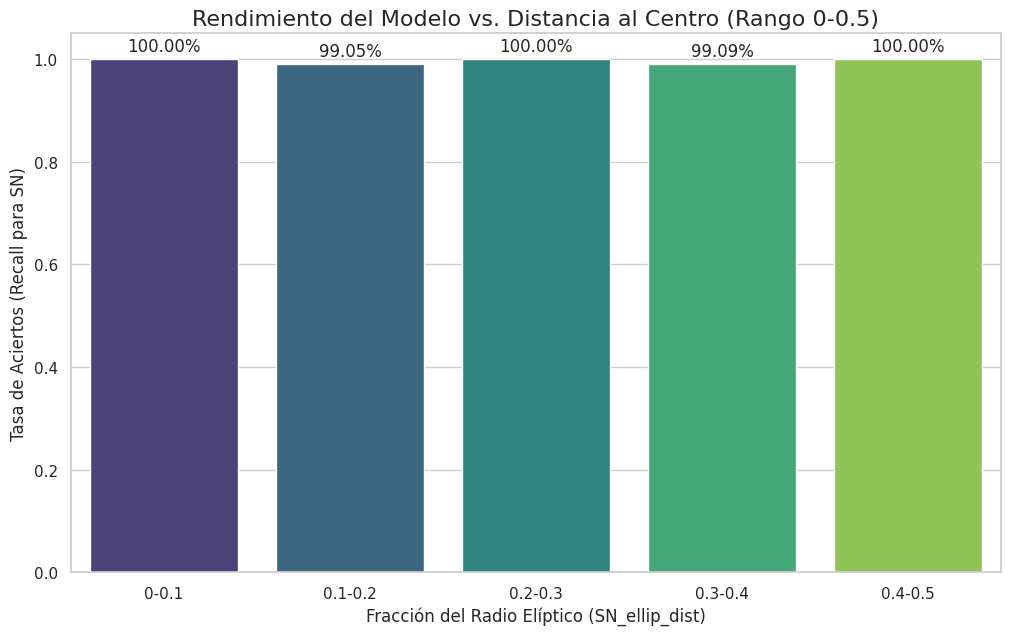

/tmp/ipykernel_2665764/3162717713.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


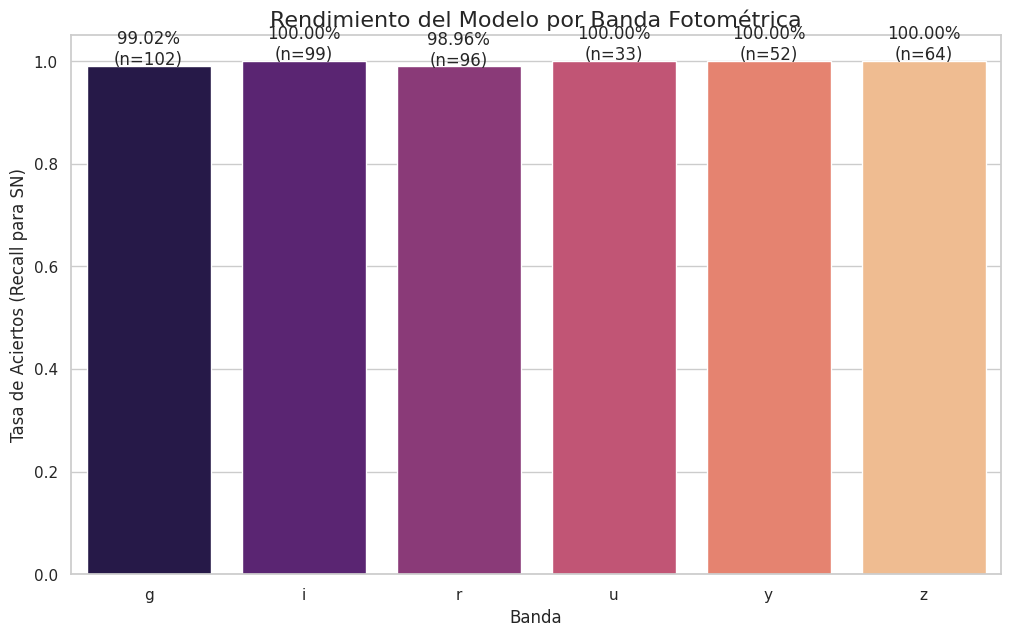

In [34]:
import seaborn as sns

# Preparación
merged_sim_df['is_correct'] = (merged_sim_df['predicted_label'] == 'SN').astype(int)
sns.set_theme(style="whitegrid")

# <--- CAMBIO PRINCIPAL AQUÍ ---

# Creamos bins más finos dentro del rango [0, 0.5]
radius_bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
radius_labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5']

merged_sim_df['radius_bin'] = pd.cut(
    merged_sim_df['SN_ellip_dist'],
    bins=radius_bins,
    labels=radius_labels,
    right=True,
    include_lowest=True # Asegura que el valor 0.0 sea incluido
)

# --- 4. Análisis por Fracción de Radio de la Galaxia (con bins ajustados) ---

# Filtramos las filas donde el bin de radio es válido para evitar errores si no hay datos en un bin
plot_data = merged_sim_df.dropna(subset=['radius_bin'])

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=plot_data,
    x='radius_bin',
    y='is_correct',
    palette='viridis',
    errorbar=None
)

# Añadir etiquetas con el valor exacto sobre cada barra
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2%}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 9),
        textcoords='offset points'
    )

plt.title('Rendimiento del Modelo vs. Distancia al Centro (Rango 0-0.5)', fontsize=16)
plt.xlabel('Fracción del Radio Elíptico (SN_ellip_dist)', fontsize=12)
plt.ylabel('Tasa de Aciertos (Recall para SN)', fontsize=12)
plt.ylim(0, 1.05)
plt.show()


# --- 5. Análisis por Banda Fotométrica (sin cambios) ---

band_counts = merged_sim_df['band'].value_counts().sort_index()
band_order = sorted(merged_sim_df['band'].unique())

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=merged_sim_df,
    x='band',
    y='is_correct',
    palette='magma',
    order=band_order,
    errorbar=None
)

for i, p in enumerate(ax.patches):
    band_name = band_order[i]
    if band_name in band_counts:
        count = band_counts[band_name]
        ax.annotate(
            f'{p.get_height():.2%}\n(n={count})',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 12),
            textcoords='offset points'
        )

plt.title('Rendimiento del Modelo por Banda Fotométrica', fontsize=16)
plt.xlabel('Banda', fontsize=12)
plt.ylabel('Tasa de Aciertos (Recall para SN)', fontsize=12)
plt.ylim(0, 1.05)
plt.show()

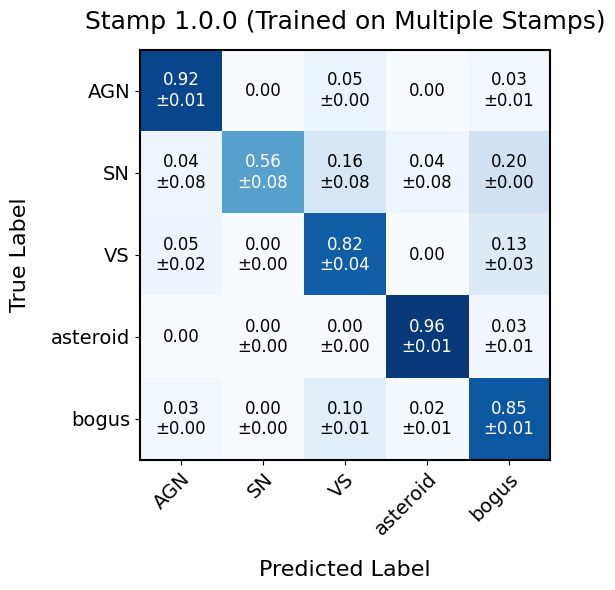

In [ ]:
# Célula 5 (Modificada): Función para Graficar la Matriz de Confusión con fuentes más grandes

def get_confusion_matrix(mean_matrix, std_matrix, order_classes):
    """
    Grafica la matriz de confusión mostrando la media y la desviación estándar.
    """
    # Graficando la matriz media
    cmap = plt.cm.Blues
    fig, ax = plt.subplots(figsize=(6, 6)) # Puedes ajustar el tamaño del gráfico si es necesario
    im = ax.imshow(mean_matrix, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)

    # Añadiendo manualmente las anotaciones con la media y desviación estándar
    for i in range(mean_matrix.shape[0]):
        for j in range(mean_matrix.shape[1]):
            mean_val = mean_matrix[i, j]
            std_val = std_matrix[i, j]
            
            if mean_val > 0.001:
                text = f'{mean_val:.2f}\n±{std_val:.2f}'
            else:
                text = f'{mean_val:.2f}'
            
            color = "white" if mean_val > 0.5 else "black"
            # Puedes ajustar el tamaño de la fuente dentro de las celdas aquí
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=12) 

    # --- Ajustes de tamaño de fuente ---
    ax.set(xticks=np.arange(len(order_classes)),
           yticks=np.arange(len(order_classes)),
           xticklabels=order_classes, 
           yticklabels=order_classes,
           #title="Stamp 0.1.1 (production)",
           ylabel='True Label',
           xlabel='Predicted Label')

    ax.set_title(
        "Stamp 1.0.0 (Trained on Multiple Stamps)",
        fontsize=18, ## <-- CAMBIO AQUÍ
        pad=15       # Espaciado entre el título y el gráfico
    )

    # Aumentar el tamaño de la fuente de los nombres de las clases (ticks)
    ax.tick_params(axis='both', which='major', labelsize=14) ## <-- CAMBIO AQUÍ

    # Aumentar el tamaño de la fuente de las etiquetas de los ejes
    ax.xaxis.label.set_size(16) ## <-- CAMBIO AQUÍ
    ax.yaxis.label.set_size(16) ## <-- CAMBIO AQUÍ
    
    # Ajustar el espaciado para que no se corten las etiquetas
    ax.xaxis.labelpad = 15 ## <-- CAMBIO AQUÍ
    ax.yaxis.labelpad = 15 ## <-- CAMBIO AQUÍ
    
    # Rotación de las etiquetas del eje x
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Añadir borde negro exterior
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)

    fig.tight_layout()
    plt.show()

order_classes = ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
get_confusion_matrix(mean_cm_norm, std_cm_norm, order_classes)

In [16]:
all_predictions[0]

,oid,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,prob_asteroid,prob_bogus
0,169364392051212498,4,4,bogus,bogus,0.434343,0.184093,0.000017,0.381500,0.000047,0.434343
1,169360000490668108,4,2,bogus,VS,0.571661,0.062115,0.000010,0.571661,0.000049,0.366165
2,169368782318862471,4,4,bogus,bogus,0.872643,0.000248,0.000003,0.125983,0.001122,0.872643
3,169355605687927642,4,4,bogus,bogus,0.970260,0.003292,0.000010,0.025823,0.000614,0.970260
4,169342391466066016,4,4,bogus,bogus,0.951035,0.000770,0.000005,0.047827,0.000364,0.951035
...,...,...,...,...,...,...,...,...,...,...,...
813,169364392197488647,4,3,bogus,asteroid,0.993502,0.000201,0.000042,0.000185,0.993502,0.006069
814,169342396864659557,4,4,bogus,bogus,0.955677,0.000377,0.000005,0.043274,0.000666,0.955677
815,169364389349031996,4,4,bogus,bogus,0.530318,0.000166,0.000143,0.001076,0.468298,0.530318
816,169368784371450454,4,4,bogus,bogus,0.698245,0.006324,0.000005,0.294938,0.000488,0.698245


Procesando 5 folds del conjunto de test.


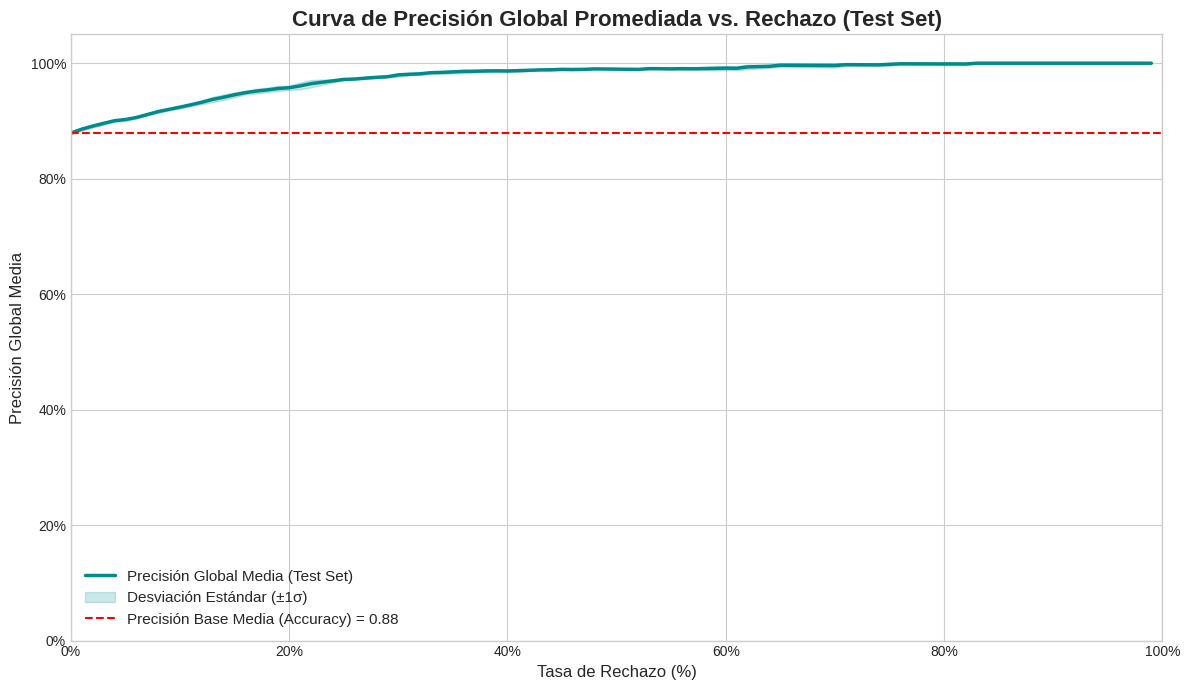


--- Interpretación de Ejemplo (Promedio en Test Set) ---
La precisión media (accuracy) sin rechazar ninguna alerta es: 87.90%
Al rechazar el 50% de las alertas con menor confianza, la precisión media aumenta a: 98.97% (con una desviación estándar de 0.10%)


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Cálculo de la Curva por Fold ---

if not isinstance(all_predictions, list) or not all(isinstance(df, pd.DataFrame) for df in all_predictions):
    raise TypeError("La variable 'all_predictions' debe ser una lista de DataFrames de pandas.")

print(f"Procesando {len(all_predictions)} folds del conjunto de test.")

rejection_rates = np.linspace(0, 0.99, 100)
precisions_per_fold = []

for i, df_fold in enumerate(all_predictions):
    # Verificar que las columnas necesarias existen
    required_cols = ['true_label', 'predicted_label', 'predicted_probability']
    if not all(col in df_fold.columns for col in required_cols):
        raise ValueError(f"El DataFrame del fold {i} no tiene las columnas requeridas: {required_cols}")

    fold_precisions = []
    scores = df_fold['predicted_probability'].values
    
    for rate in rejection_rates:
        threshold = np.quantile(scores, rate)
        df_accepted = df_fold[df_fold['predicted_probability'] >= threshold]
        
        if len(df_accepted) > 0:
            is_correct = (df_accepted['true_label'] == df_accepted['predicted_label'])
            precision = is_correct.mean()
        else:
            precision = np.nan
            
        fold_precisions.append(precision)
        
    precisions_per_fold.append(fold_precisions)

# --- Agregación de Resultados y Visualización ---

precisions_array = np.array(precisions_per_fold)

mean_precisions = np.nanmean(precisions_array, axis=0)
std_precisions = np.nanstd(precisions_array, axis=0)

upper_bound = mean_precisions + std_precisions
lower_bound = mean_precisions - std_precisions

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Línea de la precisión media
ax.plot(rejection_rates * 100, mean_precisions, 
        label='Precisión Global Media (Test Set)', 
        color='darkcyan', linewidth=2.5)

# Área sombreada para la desviación estándar
ax.fill_between(rejection_rates * 100, lower_bound, upper_bound, 
                color='darkcyan', alpha=0.2, 
                label='Desviación Estándar (±1σ)')

# Línea de base (precisión media sin rechazo)
baseline_precision = mean_precisions[0]
ax.axhline(y=baseline_precision, color='red', linestyle='--', 
           label=f'Precisión Base Media (Accuracy) = {baseline_precision:.2f}')

# Formato y etiquetas
ax.set_title('Curva de Precisión Global Promediada vs. Rechazo (Test Set)', fontsize=16, weight='bold')
ax.set_xlabel('Tasa de Rechazo (%)', fontsize=12)
ax.set_ylabel('Precisión Global Media', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))

plt.tight_layout()
plt.show()

# Imprimir un ejemplo de interpretación
idx_50_percent_rejection = np.argmin(np.abs(rejection_rates - 0.5))
precision_at_50 = mean_precisions[idx_50_percent_rejection]
std_at_50 = std_precisions[idx_50_percent_rejection]

print("\n--- Interpretación de Ejemplo (Promedio en Test Set) ---")
print(f"La precisión media (accuracy) sin rechazar ninguna alerta es: {baseline_precision:.2%}")
print(f"Al rechazar el 50% de las alertas con menor confianza, la precisión media aumenta a: {precision_at_50:.2%} (con una desviación estándar de {std_at_50:.2%})")

Procesando 5 folds para la clase 'SN' en el conjunto de test.


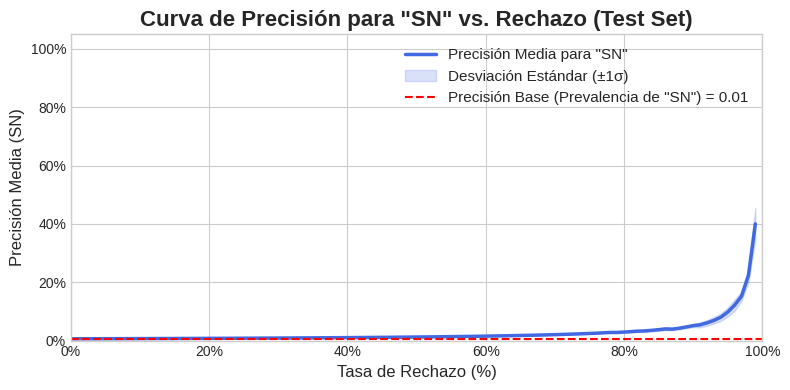


--- Interpretación de Ejemplo (Clase SN en Test Set) ---
La precisión base (prevalencia de SN en los datos) es: 0.61%
Al rechazar el 90% de las alertas con menor probabilidad de ser SN, la precisión media de las alertas restantes aumenta a: 5.12% (± 0.49%)


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Configuración del Análisis ---
POSITIVE_CLASS_NAME = 'SN'
prob_column_name = f'prob_{POSITIVE_CLASS_NAME}'

# --- Cálculo de la Curva por Fold ---
if not isinstance(all_predictions, list) or not all(isinstance(df, pd.DataFrame) for df in all_predictions):
    raise TypeError("La variable 'all_predictions' debe ser una lista de DataFrames de pandas.")

print(f"Procesando {len(all_predictions)} folds para la clase '{POSITIVE_CLASS_NAME}' en el conjunto de test.")

rejection_rates = np.linspace(0, 0.99, 100)
precisions_per_fold = []

for i, df_fold in enumerate(all_predictions):
    if prob_column_name not in df_fold.columns:
        raise ValueError(f"La columna '{prob_column_name}' no se encuentra en el DataFrame del fold {i}.")

    fold_precisions = []
    # Usamos la columna de probabilidad específica de SN como nuestro score
    scores = df_fold[prob_column_name].values
    
    for rate in rejection_rates:
        threshold = np.quantile(scores, rate)
        df_accepted = df_fold[df_fold[prob_column_name] >= threshold]
        
        if len(df_accepted) > 0:
            # Precisión = (Nº de aceptados que eran SN reales) / (Nº total de aceptados)
            is_correct = (df_accepted['true_label'] == POSITIVE_CLASS_NAME)
            precision = is_correct.mean()
        else:
            precision = np.nan
            
        fold_precisions.append(precision)
        
    precisions_per_fold.append(fold_precisions)

# --- Agregación de Resultados y Visualización ---

precisions_array = np.array(precisions_per_fold)

mean_precisions = np.nanmean(precisions_array, axis=0)
std_precisions = np.nanstd(precisions_array, axis=0)

upper_bound = mean_precisions + std_precisions
lower_bound = mean_precisions - std_precisions

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 4))

# Línea de la precisión media
ax.plot(rejection_rates * 100, mean_precisions, 
        label=f'Precisión Media para "{POSITIVE_CLASS_NAME}"', 
        color='royalblue', linewidth=2.5)

# Área sombreada para la desviación estándar
ax.fill_between(rejection_rates * 100, lower_bound, upper_bound, 
                color='royalblue', alpha=0.2, 
                label='Desviación Estándar (±1σ)')

# Línea de base (prevalencia de la clase en el test set)
baseline_precision = mean_precisions[0]
ax.axhline(y=baseline_precision, color='red', linestyle='--', 
           label=f'Precisión Base (Prevalencia de "{POSITIVE_CLASS_NAME}") = {baseline_precision:.2f}')

# Formato y etiquetas
ax.set_title(f'Curva de Precisión para "{POSITIVE_CLASS_NAME}" vs. Rechazo (Test Set)', fontsize=16, weight='bold')
ax.set_xlabel('Tasa de Rechazo (%)', fontsize=12)
ax.set_ylabel(f'Precisión Media ({POSITIVE_CLASS_NAME})', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))

plt.tight_layout()
plt.show()

# Imprimir un ejemplo de interpretación
idx_90_percent_rejection = np.argmin(np.abs(rejection_rates - 0.90))
precision_at_90 = mean_precisions[idx_90_percent_rejection]
std_at_90 = std_precisions[idx_90_percent_rejection]

print("\n--- Interpretación de Ejemplo (Clase SN en Test Set) ---")
print(f"La precisión base (prevalencia de SN en los datos) es: {baseline_precision:.2%}")
if not np.isnan(precision_at_90):
    print(f"Al rechazar el 90% de las alertas con menor probabilidad de ser SN, la precisión media de las alertas restantes aumenta a: {precision_at_90:.2%} (± {std_at_90:.2%})")

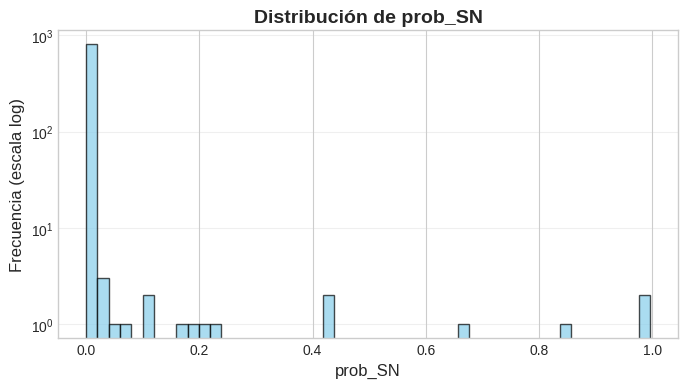

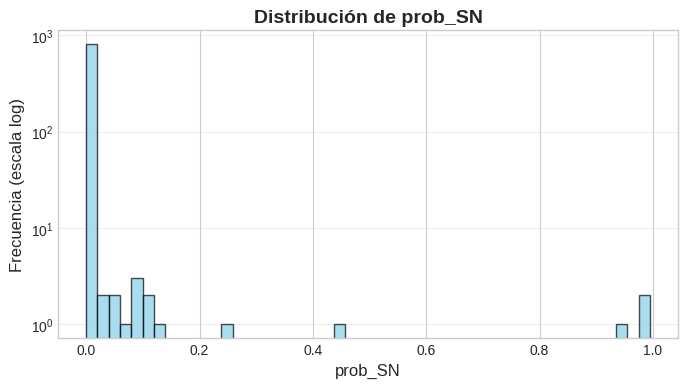

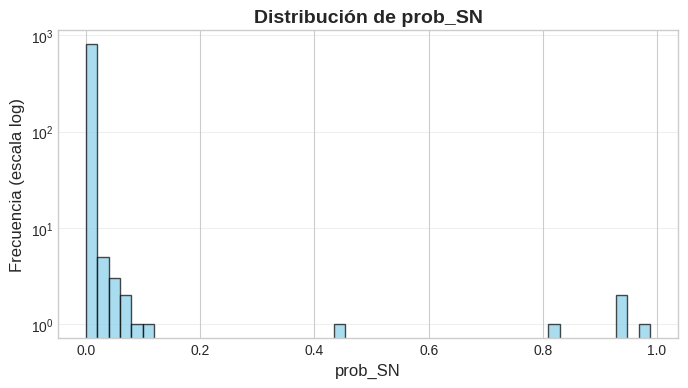

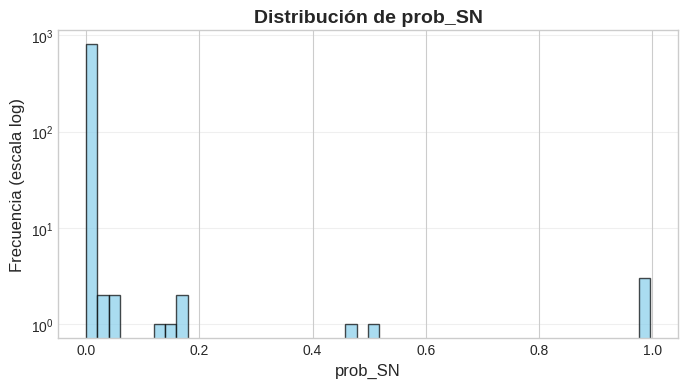

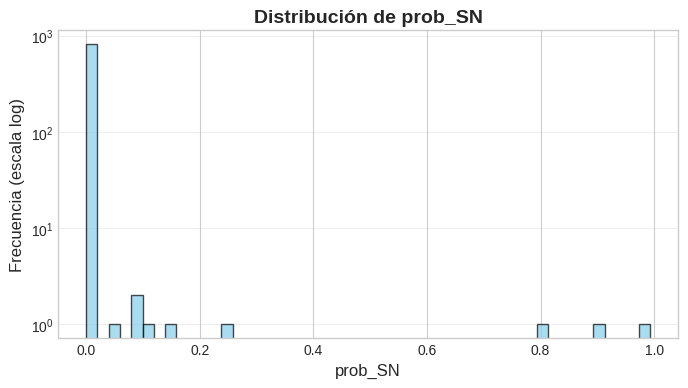

In [19]:
import matplotlib.pyplot as plt

for df_fold in all_predictions:
    plt.figure(figsize=(8, 4))
    df_fold[prob_column_name].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'Distribución de {prob_column_name}', fontsize=14, fontweight='bold')
    plt.xlabel(prob_column_name, fontsize=12)
    plt.ylabel('Frecuencia (escala log)', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.yscale('log')  # Escala logarítmica en el eje Y
    plt.show()

In [20]:
sn = df_fold[df_fold.true_label == 'SN']
sn

,oid,true_label_int,predicted_label_int,true_label,predicted_label,predicted_probability,prob_AGN,prob_SN,prob_VS,prob_asteroid,prob_bogus
218,169355604935573556,1,1,SN,SN,0.992497,0.000018,0.992497,0.000021,0.007409,0.000055
219,169342396737257673,1,1,SN,SN,0.802814,0.002947,0.802814,0.192226,0.001865,0.000148
220,169342396578398273,1,3,SN,asteroid,0.565010,0.008705,0.115861,0.309919,0.565010,0.000505
221,21164710903756869,1,4,SN,bogus,0.986402,0.003338,0.000011,0.010219,0.000030,0.986402
222,21163628757006675,1,0,SN,AGN,0.802352,0.802352,0.084268,0.099232,0.001836,0.012312


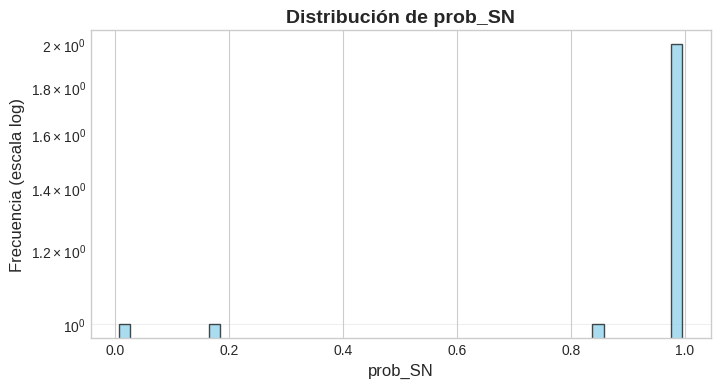

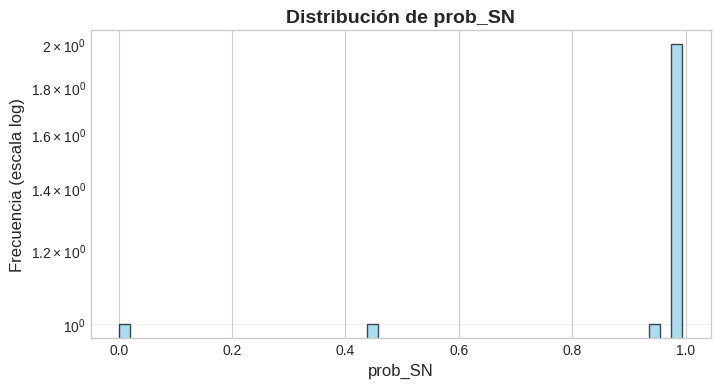

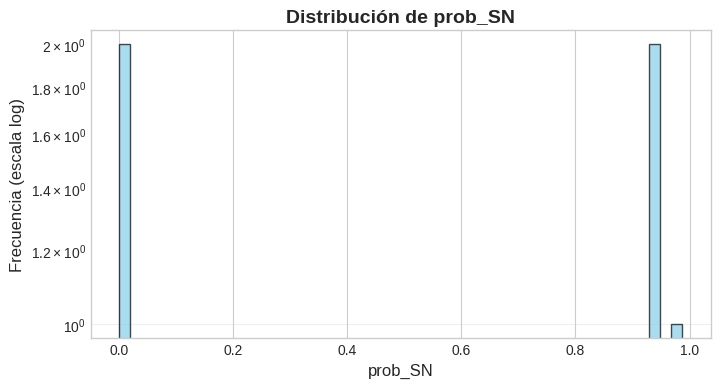

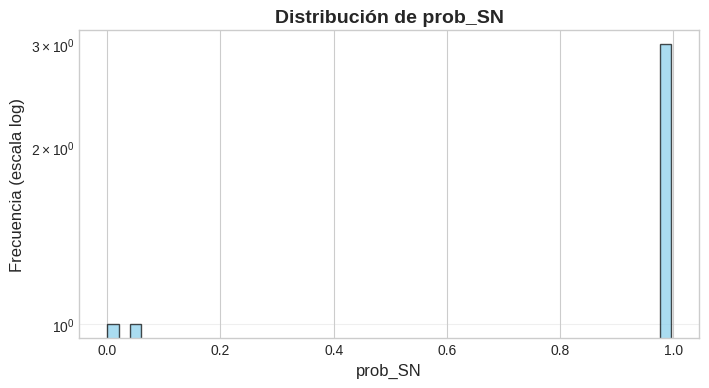

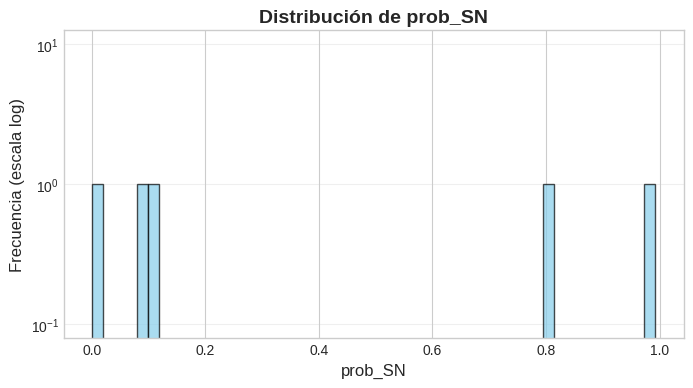

In [21]:
for df_fold in all_predictions:
    sn = df_fold[df_fold.true_label == 'SN']
    plt.figure(figsize=(8, 4))
    sn[prob_column_name].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title(f'Distribución de {prob_column_name}', fontsize=14, fontweight='bold')
    plt.xlabel(prob_column_name, fontsize=12)
    plt.ylabel('Frecuencia (escala log)', fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.yscale('log')  # Escala logarítmica en el eje Y
    plt.show()

In [22]:
class_map = {
    0: "AGN",
    1: "SN",
    2: "VS",
    3: "asteroid",
    4: "bogus"
}

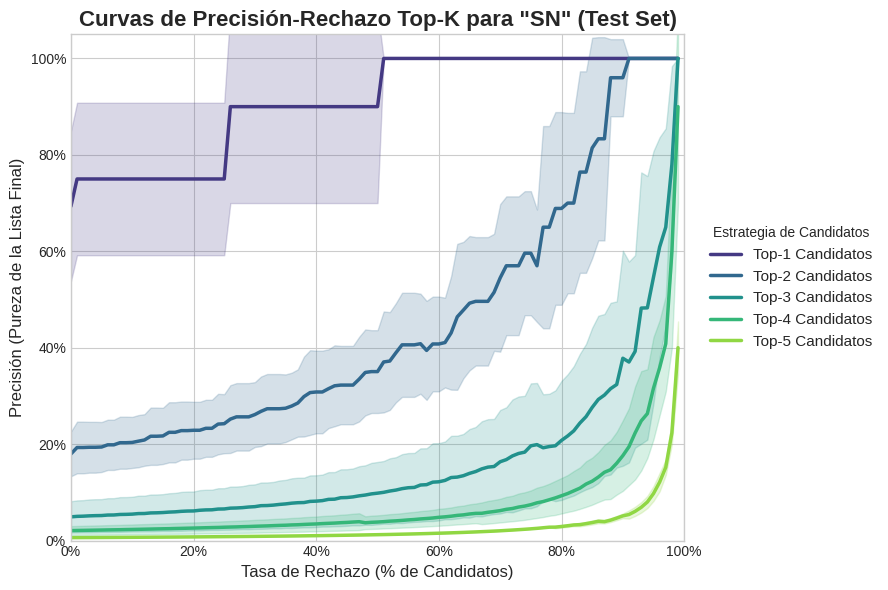

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


# --- Configuración del Análisis (sin cambios) ---
TARGET_CLASS_NAME = 'SN'
prob_columns = [f'prob_{name}' for name in class_map.values()]
class_map_inv = {v: k for k, v in class_map.items()}
target_class_id = class_map_inv[TARGET_CLASS_NAME]
prob_column_name = f'prob_{TARGET_CLASS_NAME}'

k_values = [1, 2, 3, 4, 5]
rejection_rates = np.linspace(0, 0.99, 100)

all_curves_data = {k: [] for k in k_values}

# --- Bucle principal por Fold (sin cambios) ---
for df_fold in all_predictions:
    probs = df_fold[prob_columns].to_numpy()
    sorted_class_indices = np.argsort(probs, axis=1)[:, ::-1]
    
    for k in k_values:
        top_k_indices = sorted_class_indices[:, :k]
        is_candidate = np.any(top_k_indices == target_class_id, axis=1)
        df_candidates_k = df_fold[is_candidate]
        
        if len(df_candidates_k) == 0:
            all_curves_data[k].append([np.nan] * len(rejection_rates))
            continue

        fold_precisions = []
        scores = df_candidates_k[prob_column_name].values
        
        for rate in rejection_rates:
            if len(scores) < 2:
                fold_precisions.append(np.nan)
                continue
                
            threshold = np.quantile(scores, rate)
            df_accepted = df_candidates_k[df_candidates_k[prob_column_name] >= threshold]
            
            if len(df_accepted) > 0:
                is_correct = (df_accepted['true_label'] == TARGET_CLASS_NAME)
                precision = is_correct.mean()
            else:
                precision = np.nan
                
            fold_precisions.append(precision)
        
        all_curves_data[k].append(fold_precisions)

# --- Agregación y Visualización (Con la leyenda afuera) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette("viridis", n_colors=len(k_values))

for i, k in enumerate(k_values):
    precisions_array = np.array(all_curves_data[k])
    
    mean_precisions = np.nanmean(precisions_array, axis=0)
    std_precisions = np.nanstd(precisions_array, axis=0)
    upper_bound = mean_precisions + std_precisions
    lower_bound = mean_precisions - std_precisions
    
    if not np.all(np.isnan(mean_precisions)):
        ax.plot(rejection_rates * 100, mean_precisions, 
                label=f'Top-{k} Candidatos', 
                color=palette[i], linewidth=2.5)
        
        ax.fill_between(rejection_rates * 100, lower_bound, upper_bound,
                        color=palette[i], alpha=0.2)

# Formato y etiquetas
ax.set_title(f'Curvas de Precisión-Rechazo Top-K para "{TARGET_CLASS_NAME}" (Test Set)', fontsize=16, weight='bold')
ax.set_xlabel('Tasa de Rechazo (% de Candidatos)', fontsize=12)
ax.set_ylabel('Precisión (Pureza de la Lista Final)', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))

# --- LÍNEA MODIFICADA PARA MOVER LA LEYENDA ---
ax.legend(title="Estrategia de Candidatos", fontsize=11, 
          bbox_to_anchor=(1.02, 0.5), loc='center left')
# ---------------------------------------------

# Ajusta el layout para asegurar que la leyenda quepa
plt.tight_layout()
plt.show()

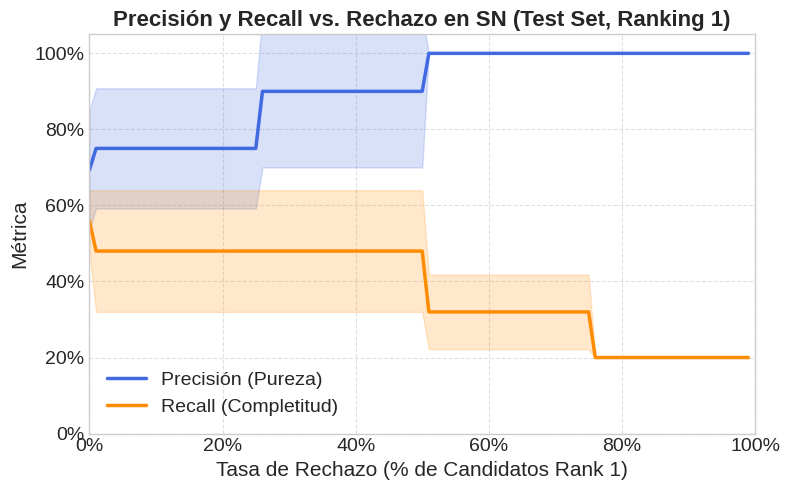

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Asumimos que 'all_predictions', 'tables' y 'class_map' ya existen ---
# (Usaré mocks para que el código sea ejecutable)
# ----------------- INICIO DEL MOCK DATA -----------------
def create_mock_predictions_sn(num_rows=800, num_folds=5): # Test Set Data
    mock_list = []
    labels = ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
    label_p = [0.1, 0.02, 0.15, 0.25, 0.48]
    for i in range(num_folds):
        df = pd.DataFrame()
        df['true_label'] = np.random.choice(labels, num_rows, p=label_p)
        probs = np.random.rand(num_rows, len(labels))
        # Make SN probs higher for real SNs and for predicted SNs
        true_sn_indices = df[df['true_label'] == 'SN'].index
        probs[true_sn_indices, 1] = np.clip(probs[true_sn_indices, 1] + 0.6, 0, 1)
        probs = probs / probs.sum(axis=1, keepdims=True)
        for idx, label_name in enumerate(labels):
             df[f'prob_{label_name}'] = probs[:, idx]
        df['predicted_label'] = pd.Index(labels)[np.argmax(probs, axis=1)]
        mock_list.append(df)
    return mock_list

def create_mock_tables(num_rows=20000): # Production Data
    df = pd.DataFrame()
    df['class_id'] = np.random.choice([0, 1, 2, 3, 4], num_rows, p=[0.05, 0.2, 0.3, 0.15, 0.3])
    df['ranking'] = np.random.randint(1, 6, num_rows)
    probs = np.random.beta(a=2, b=15, size=num_rows) + (1 - (df['ranking'] / 5)) * 0.3
    sn_indices = df[df['class_id'] == 0].index
    probs[sn_indices] = probs[sn_indices] + np.random.uniform(0, 0.4, size=len(sn_indices))
    df['probability'] = np.clip(probs, 0.01, 1.0)
    return df

class_map = {0: 'AGN', 1: 'SN', 2: 'VS', 3: 'asteroid', 4: 'bogus'}
if 'all_predictions' not in locals():
    print("Usando datos de ejemplo (mock) para 'all_predictions'.")
    all_predictions = create_mock_predictions_sn()
if 'tables' not in locals():
    print("Usando datos de ejemplo (mock) para 'tables'.\n")
    tables = create_mock_tables()
# ----------------- FIN DEL MOCK DATA -----------------


# --- Configuración del Análisis ---
TARGET_CLASS_NAME = 'SN'
SN_CLASS_ID = 1 # Asumo ID=1 para SN, cámbialo si es necesario
prob_column_name = f'prob_{TARGET_CLASS_NAME}'
rejection_rates = np.linspace(0, 0.99, 100)

# --- Creación de los Subplots ---
fig, ax1 = plt.subplots(figsize=(8, 5))
#ax1, ax2 = axes[0], axes[1]

# ==============================================================================
# GRÁFICO 1: ANÁLISIS EN EL CONJUNTO DE TEST (all_predictions)
# ==============================================================================
precisions_per_fold = []
recalls_per_fold = []

for df_fold in all_predictions:
    # El denominador del Recall: el número total de SN reales en este fold
    total_true_sns_in_fold = (df_fold['true_label'] == TARGET_CLASS_NAME).sum()

    # Filtramos para quedarnos solo con los candidatos de Ranking 1
    # En este dataset, Ranking 1 significa que la predicción fue SN
    candidates_rank1 = df_fold[df_fold['predicted_label'] == TARGET_CLASS_NAME]
    
    fold_precisions, fold_recalls = [], []
    scores = candidates_rank1[prob_column_name].values
    
    for rate in rejection_rates:
        if len(scores) < 2 or total_true_sns_in_fold == 0:
            fold_precisions.append(np.nan)
            fold_recalls.append(np.nan)
            continue
            
        threshold = np.quantile(scores, rate)
        df_accepted = candidates_rank1[candidates_rank1[prob_column_name] >= threshold]
        
        if len(df_accepted) > 0:
            # Precisión
            is_correct = (df_accepted['true_label'] == TARGET_CLASS_NAME)
            precision = is_correct.mean()
            # Recall
            true_positives = is_correct.sum()
            recall = true_positives / total_true_sns_in_fold
        else:
            precision, recall = np.nan, 0 # Si no aceptamos nada, la precisión es indefinida y el recall es 0
            
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        
    precisions_per_fold.append(fold_precisions)
    recalls_per_fold.append(fold_recalls)

# --- Agregación y Visualización para Test Set ---
# Precisión
mean_precisions = np.nanmean(precisions_per_fold, axis=0)
std_precisions = np.nanstd(precisions_per_fold, axis=0)
# Recall
mean_recalls = np.nanmean(recalls_per_fold, axis=0)
std_recalls = np.nanstd(recalls_per_fold, axis=0)

# Graficar Precisión
ax1.plot(rejection_rates * 100, mean_precisions, label='Precisión (Pureza)', color='royalblue', lw=2.5)
ax1.fill_between(rejection_rates * 100, mean_precisions - std_precisions, mean_precisions + std_precisions, color='royalblue', alpha=0.2)

# Graficar Recall
ax1.plot(rejection_rates * 100, mean_recalls, label='Recall (Completitud)', color='darkorange', lw=2.5)
ax1.fill_between(rejection_rates * 100, mean_recalls - std_recalls, mean_recalls + std_recalls, color='darkorange', alpha=0.2)
ax1.set_title('Precisión y Recall vs. Rechazo en SN (Test Set, Ranking 1)', fontsize=16, weight='bold')
ax1.set_xlabel('Tasa de Rechazo (% de Candidatos Rank 1)', fontsize=15)
ax1.set_ylabel('Métrica', fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=14)

ax1.set_ylim(0, 1.05)
ax1.set_xlim(0, 100)

ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))
ax1.legend(fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)

# ==============================================================================
# GRÁFICO 2: ANÁLISIS EN PRODUCCIÓN (tables)
# ==============================================================================
# Denominador del Recall: Total de SN reales en producción
total_true_sns_in_prod = (tables['class_id'] == SN_CLASS_ID).sum()

# Filtramos para candidatos de Ranking 1
prod_candidates_rank1 = tables[
    (tables.class_id == SN_CLASS_ID) & # Esto es para producción, así que asumimos que class_id es el tipo de objeto
    (tables.ranking == 1)
]

prod_precisions, prod_recalls = [], []
prod_scores = prod_candidates_rank1['probability'].values

for rate in rejection_rates:
    if len(prod_scores) < 2 or total_true_sns_in_prod == 0:
        prod_precisions.append(np.nan)
        prod_recalls.append(np.nan)
        continue

    threshold = np.quantile(prod_scores, rate)
    df_accepted = prod_candidates_rank1[prod_candidates_rank1.probability >= threshold]
    
    if len(df_accepted) > 0:
        # En producción, la precisión de los candidatos de Rank 1 es siempre 100% por definición
        precision = 1.0 
        true_positives = len(df_accepted)
        recall = true_positives / total_true_sns_in_prod
    else:
        precision, recall = np.nan, 0
    
    prod_precisions.append(precision)
    prod_recalls.append(recall)

# --- Visualización para Producción ---
#ax2.plot(rejection_rates * 100, prod_precisions, label='Precisión (Pureza)', color='royalblue', lw=2.5)
#ax2.plot(rejection_rates * 100, prod_recalls, label='Recall (Completitud)', color='darkorange', lw=2.5)
#ax2.set_title('Precisión y Recall vs. Rechazo (Producción, Ranking 1)', fontsize=14, weight='bold')
#ax2.set_xlabel('Tasa de Rechazo (% de Candidatos Rank 1)', fontsize=12)

# --- Formato Final para Ambos Gráficos ---
#for ax in axes:
#    ax.set_ylim(0, 1.05)
#    ax.set_xlim(0, 100)
#    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
#    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))
#    ax.legend()
#    ax.grid(True, linestyle='--', alpha=0.6)

#fig.suptitle('Análisis del Trade-off Precisión-Recall para Candidatos a SN de Ranking 1', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df_fold[prob_column_name].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title(f'Distribución de {prob_column_name}', fontsize=14, fontweight='bold')
plt.xlabel(prob_column_name, fontsize=12)
plt.ylabel('Frecuencia (escala log)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.yscale('log')  # Escala logarítmica en el eje Y
plt.show()

Procesando 5 folds del conjunto de test.


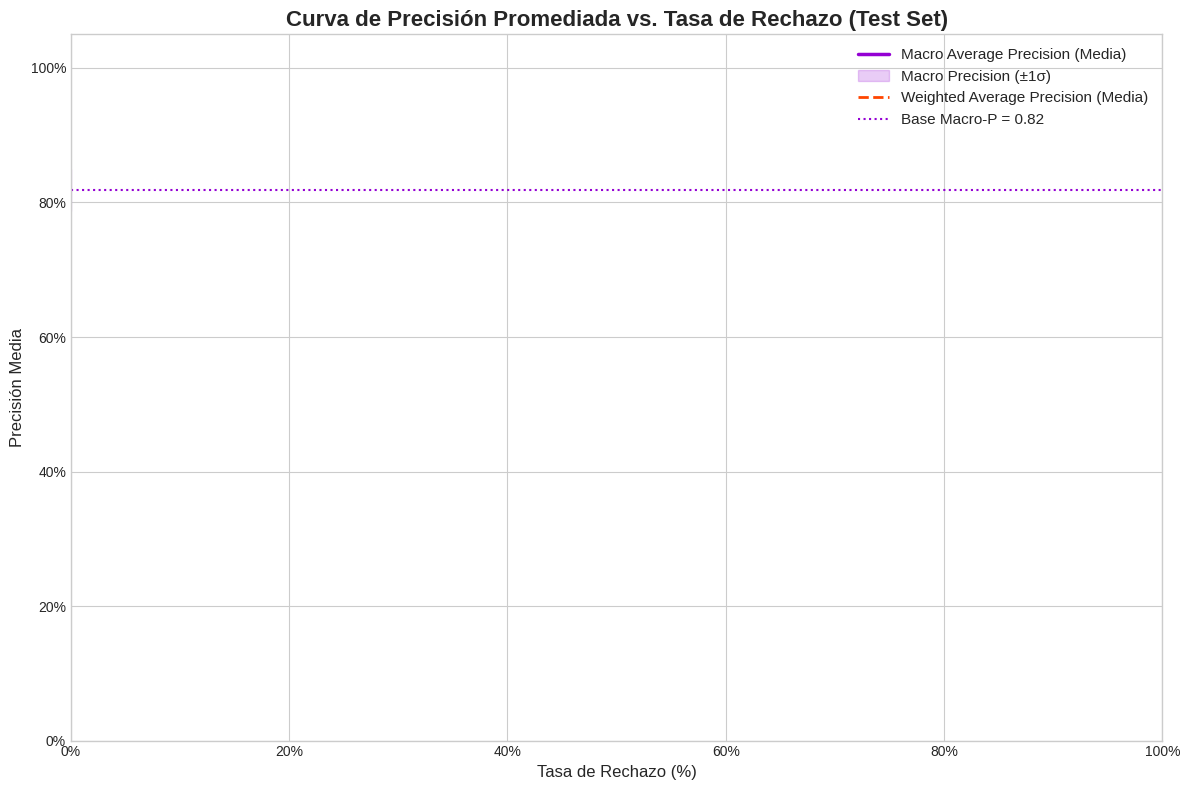

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import precision_score



print(f"Procesando {len(all_predictions)} folds del conjunto de test.")

rejection_rates = np.linspace(0, 0, 100)
macro_precisions_per_fold = []
weighted_precisions_per_fold = []

all_labels = pd.concat(all_predictions)['true_label'].unique()

for i, df_fold in enumerate(all_predictions):
    fold_macro_p = []
    fold_weighted_p = []
    scores = df_fold['predicted_probability'].values
    
    for rate in rejection_rates:
        threshold = np.quantile(scores, rate)
        df_accepted = df_fold[df_fold['predicted_probability'] >= threshold]
        
        if len(df_accepted) > 1: # Necesitamos al menos 2 muestras para un cálculo estable
            y_true = df_accepted['true_label']
            y_pred = df_accepted['predicted_label']
            
            # Calcular Macro Precision
            macro_p = precision_score(y_true, y_pred, labels=all_labels, average='macro', zero_division=0)
            fold_macro_p.append(macro_p)
            
            # Calcular Weighted Precision
            weighted_p = precision_score(y_true, y_pred, labels=all_labels, average='weighted', zero_division=0)
            fold_weighted_p.append(weighted_p)
        else:
            fold_macro_p.append(np.nan)
            fold_weighted_p.append(np.nan)
            
    macro_precisions_per_fold.append(fold_macro_p)
    weighted_precisions_per_fold.append(fold_weighted_p)

# --- Agregación de Resultados y Visualización ---

# Macro Precision
mean_macro_p = np.nanmean(macro_precisions_per_fold, axis=0)
std_macro_p = np.nanstd(macro_precisions_per_fold, axis=0)

# Weighted Precision
mean_weighted_p = np.nanmean(weighted_precisions_per_fold, axis=0)
std_weighted_p = np.nanstd(weighted_precisions_per_fold, axis=0)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

# Trazar Macro Precision
ax.plot(rejection_rates * 100, mean_macro_p, 
        label='Macro Average Precision (Media)', 
        color='darkviolet', linewidth=2.5)
ax.fill_between(rejection_rates * 100, mean_macro_p - std_macro_p, mean_macro_p + std_macro_p, 
                color='darkviolet', alpha=0.2, label='Macro Precision (±1σ)')

# Trazar Weighted Precision
ax.plot(rejection_rates * 100, mean_weighted_p, 
        label='Weighted Average Precision (Media)', 
        color='orangered', linestyle='--', linewidth=2)

# Línea de base
baseline_macro = mean_macro_p[0]
ax.axhline(y=baseline_macro, color='darkviolet', linestyle=':', 
           label=f'Base Macro-P = {baseline_macro:.2f}')

# Formato y etiquetas
ax.set_title('Curva de Precisión Promediada vs. Tasa de Rechazo (Test Set)', fontsize=16, weight='bold')
ax.set_xlabel('Tasa de Rechazo (%)', fontsize=12)
ax.set_ylabel('Precisión Media', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 100)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, symbol='%'))

plt.tight_layout()
plt.show()

In [18]:
condicion_true_sn = (predictions['true_label'] == 'SN')
condicion_predicted_vs = (predictions['predicted_label'] == 'AGN')

# Aplicamos ambas condiciones al DataFrame
sn_confundidos_con_vs = predictions[condicion_true_sn & condicion_predicted_vs]


# --- 3. Mostrar los resultados ---
print("Supernovas (SN) clasificadas erróneamente como Estrellas Variables (AGN):")
print("="*70)

if sn_confundidos_con_vs.empty:
    print("No se encontraron Supernovas clasificadas como Estrellas Variables en los datos.")
else:
    print(sn_confundidos_con_vs)

Supernovas (SN) clasificadas erróneamente como Estrellas Variables (AGN):
No se encontraron Supernovas clasificadas como Estrellas Variables en los datos.
